## figure out normalization and difference from last time...


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import h5py
import pandas as pd
from numba import njit
# from scipy import odr
# from scipy.special import voigt_profile
from scipy.optimize import curve_fit
# from scipy import stats as st
import time

# os.chdir('F:/LANL/processed_data/')
# processedfolder = 'F:/LANL/processed_data/'

os.chdir('F:/LANL/')
# os.chdir('/mnt/c/Users/gabeo/Desktop/analysis_temp/')
root = os.getcwd()

processedfolder = '/processed_data/'

search_arr = sorted(os.listdir(root + processedfolder))
print(search_arr)
# print(search_arr[0])

# folders_start = 'runs'+'12686-13279'
# folders_end = 'runs'+'12686-13279'
folders_start = 'runs'+'12686-13279'
folders_end = 'runs'+'13564-13604'

print(folders_start)
start_i = search_arr.index(folders_start)
end_i = search_arr.index(folders_end)
print(start_i, end_i)
print(len(search_arr[start_i:end_i+1]))
asymDendname = '/asym_D/'
asymUendname = '/asym_U/'

firstfile = sorted(os.listdir(root+processedfolder+folders_start+asymDendname))[0]
folderslist = []
if folders_start == folders_end:
    currfolder = search_arr[start_i]+'/'
    folderslist.append(currfolder)
else:
    for f in range(start_i, end_i+1):
#         print(f)
#         print(search_arr[f])
        currfolder = root+processedfolder+search_arr[f]
        currfolder = search_arr[f]+'/'
#         print(currfolder)
        folderslist.append(currfolder)
#     runslist_D[f] = sorted(os.listdir(root+processedfolder+folders_start+'/asym_D'))
#     runslist_U[f] = sorted(os.listdir(root+processedfolder+folders_start+'/asym_U'))

numfolders = len(folderslist)
print(folderslist)
print(numfolders)

## change below to multiple folders?
runslist_D = []  ## array of runfolders, runs
runslist_U = []
for i in range(len(folderslist)):
    runslist_D.append(sorted(os.listdir(root+processedfolder+folderslist[i]+asymDendname)))
    runslist_U.append(sorted(os.listdir(root+processedfolder+folderslist[i]+asymUendname)))
# runslist_D = sorted(os.listdir(root+processedfolder+folders_start+'/ONOFF_D')) ## has to be changed to an array
# runslist_U = sorted(os.listdir(root+processedfolder+folders_start+'/ONOFF_U'))
# runslist_D =np.asarray(runslist_D)
# runslist_U =np.asarray(runslist_U)
print(len(runslist_D))
print(len(runslist_D[0]))
# print(len(runslist_D[1]))
## now flatten list so that all runs are in one array ## not sure I will use this
flatrunslist_D = [run for folder in runslist_D for run in folder]
flatrunslist_D = np.asarray(flatrunslist_D)
flatrunslist_U = [run for folder in runslist_U for run in folder]
flatrunslist_U = np.asarray(flatrunslist_U)
print(len(flatrunslist_D))

numruns_tot_D = len(flatrunslist_D) ## U and D should be the same? ## should change to num pulses maybe
numruns_tot_U = len(flatrunslist_U) ## 
if numruns_tot_D != numruns_tot_U:
    emessage = ('# upstream files and downstream files are not the same!')
    # logger.error(run_num + emessage)
    raise Exception(emessage)
print(numruns_tot_D)
print(numruns_tot_U)

In [ ]:
## allows h5 loads to be easier...
foldersflat = []
for i in range(0,len(folderslist)):
    folder = folderslist[i]
    numrunsfolder = len(runslist_D[i])
    fpaths = [folder]*numrunsfolder
    foldersflat.append(fpaths)

foldersflat = [path for folder in foldersflat for path in folder]
# print(foldersflat[0])
print(len(foldersflat))
# print(len(foldersflat[0]))
# print(len(foldersflat[1]))
# print(len(foldersflat))
# print(foldersflat)

In [ ]:
# print(len(runslist_D))
# print(len(runslist_D[0]))
# print(len(runslist_D[1]))
# ## now flatten list so that all runs are in one array ## not sure I will use this
# flatrunslist_D = [run for folder in runslist_D for run in folder]
# flatrunslist_D = np.asarray(flatrunslist_D)
# flatrunslist_U = [run for folder in runslist_U for run in folder]
# flatrunslist_U = np.asarray(flatrunslist_U)
# print(len(flatrunslist_D))

# numruns_tot_D = len(flatrunslist_D) ## U and D should be the same? ## should change to num pulses maybe
# numruns_tot_U = len(flatrunslist_U) ## 
# print(numruns_tot_D)
# print(numruns_tot_U)

In [ ]:
## load in the x array. Also helps in determining sizes
## NO 6LI FOR THESE HDF5 FILES

channels_all = []
folderpath = root+processedfolder+folderslist[0]
with h5py.File(folderpath+asymDendname+runslist_D[0][0], 'r') as f: ## new arr_sizer
    channels_D = list(f.keys())
    channels_all.append(channels_D[:-1])
    numchannels = len(channels_D)-1
    dataset = f[channels_D[-1]]   ## this is the xs dataset
#     xs = np.array(dataset)*1e-6 ## now in ms
#     numpoints = len(xs)
    f.close()
    
with h5py.File(folderpath+asymUendname+runslist_U[0][0], 'r') as f: ## new arr_sizer
    channels_U = list(f.keys())
    channels_all=np.append(channels_all, channels_U[:-1])
#     channels_all.append(channels[:-1])
    numchannels = len(channels_U)-1
    dataset = f[channels_U[-1]]   ## this is the xs dataset
    xs = np.array(dataset)*1e-6 ## now in ms
    numpoints = len(xs)
    f.close()
# print(channels_all)
# channels_all = np.asarray(channels_all, dtype=object)
# print(channels_all)
# channels_all = channels_all.flatten()
print(numruns_tot_D,numchannels,numpoints)
# print(data.shape)
# print(data[seq][0][0])
# print(channels_all[:])
print(channels_all[-1])
print(len(xs))

print(channels_D)
print(channels_U)
print(channels_all)

# print(channels_all.flatten())
# print(data)

In [ ]:
# ## loads on/off added pulses. not needed for asym based on multiplicative factor ##
numsequences = []
run_ampasym_D = []
run_ampasym_U = []
run_rawasym_D = []
run_rawasym_U = []
# totnumchan = len(run_asyms_D[0])+len(run_asyms_U_noLi[0])

folderpath = root+processedfolder+folderslist[0]  ## generalize this to all folders

for i in range(0,len(runslist_D)):
    runname = folderpath+asymDendname+runslist_D[0][i]  ##[0] indicates the first folder
    print(runname)
    with h5py.File(runname, 'r') as f:
        # print("Keys: %s" % f.keys())
        channels = list(f.keys())
        numchannels = len(channels)-1
        num_seq = f.attrs.get('sequences')
        numsequences.append(num_seq)
        runamp = []
        runraw = []
#             print(str(np.char.zfill(str(chan_enab[i]),2)))
#             dataset = f['ch '+str(np.char.zfill(str(chan_enab[i]), 2))]
        for i in range(0,numchannels):
            chsubgrp = f[channels[i]]  ##change this to match channels[i]
            print(chsubgrp)
# #             print(list(chsubgrp.attrs))
#             print((chsubgrp.attrs.get('asym_amp')))
            # asym_amp_data = np.array(chsubgrp.attrs.get('asym_amp'))
            # print(asym_amp_data[0])
            asym_raw_chdataset = np.array(chsubgrp['asym_raw'])
#             print(asym_raw_chdataset)
            # runamp.append(asym_amp_data)
            runraw.append(asym_raw_chdataset)
        run_ampasym_D.append(runamp)
        run_rawasym_D.append(runraw)
        f.close()
#         folderpath = root+processedfolder+folderslist[0]  ## generalize this to all folders


In [ ]:

def loadrun_asym(run, processedpath): ## not sure if this is the fastest way, or passing a list of runs...
    runname = processedpath+run
    runamp = []
    runintegral = []
#     print(runname)
#     numsequences = []
    with h5py.File(runname, 'r') as f:
        channels = list(f.keys())
        numchannels = len(channels)-1
        num_seq = f.attrs.get('sequences')
        puck = f.attrs.get('puck_state')
#         print(puck)
        # if puck != 0:
        #     print(run, puck)
        runraw = np.zeros((numchannels,numpoints),dtype = np.float64) ## numpoints gotten from few cells up
        for i in range(0,numchannels):
            chsubgrp = f[channels[i]]
            # print(chsubgrp.name[1:])
            chraw = np.array(chsubgrp['asym_raw'])  ##change this to match channels[i]
            runraw[i] = runraw[i]+chraw
            if chsubgrp.name[1:] != 'ch_24': 
                # print('6Li')
                runampch = np.array(chsubgrp.attrs.get('asym_amp'))
                runamp.append(runampch[0])  #[0] is the asym from amp as opposed to the error [1]
                runintegralch = chsubgrp.attrs.get('asym_integral')
                runintegral.append(runintegralch)  # currently no error for integral, just scaler
        f.close()
#     print((runamp))
#     print(num_seq)
    return runraw, runamp, runintegral, num_seq 

start=time.time()
# all_D = [] ## in this case cannot be np array because it is not same size arrays ## will be run, channel, numpoints
all_raw_D = np.zeros((numruns_tot_D, numchannels,numpoints),dtype = np.float64) ## run, channel, numpoints ## works if flatten the folders
all_raw_U = np.zeros((numruns_tot_U, numchannels,numpoints),dtype = np.float64) ## run, channel, numpoints ## works if flatten the folders
all_amp_D = np.zeros((numruns_tot_D, numchannels-1),dtype = np.float64) ## run, channel. amplitude only for the NaI detectors
all_amp_U = np.zeros((numruns_tot_U, numchannels-1),dtype = np.float64) ## run, channel. amplitude only for the NaI detectors
all_integral_D = np.zeros((numruns_tot_D, numchannels-1),dtype = np.float64) ## run, channel 
all_integral_U = np.zeros((numruns_tot_U, numchannels-1),dtype = np.float64) ## run, channel 
all_sequences = np.zeros((numruns_tot_D),dtype = np.float64) ## num runs
# print(len(all_amp_D))

for r in range(0, len(flatrunslist_D)):
    fpath = root+processedfolder+foldersflat[r]
    full = len(flatrunslist_D)
#     print(fpath)
#     print(len(all_amp_D[r]))
    if r == round(full/5) or r == round(2*full/5) or r == round(3*full/5) or r == round(4*full/5) or r == full-1:
        print('1/5 runs complete ', r)
#     print(flatrunslist_D[r])
    all_raw_D[r], all_amp_D[r], all_integral_D[r], all_sequences[r] = loadrun_asym(flatrunslist_D[r], fpath+asymDendname)
    all_raw_U[r], all_amp_U[r], all_integral_U[r], all_sequences[r] = loadrun_asym(flatrunslist_U[r], fpath+asymUendname)

print(all_raw_D.shape)
all_raw_D = np.asarray(all_raw_D.transpose(1,0,2))  ## re-shape into ch, run, points
all_raw_U = np.asarray(all_raw_U.transpose(1,0,2))
print(all_raw_D.shape)

print(all_amp_D.shape)
all_amp_D = np.asarray(all_amp_D.transpose(1,0))
all_amp_U = np.asarray(all_amp_U.transpose(1,0))
print(all_amp_D.shape)

print(all_amp_D.shape)
all_integral_D = np.asarray(all_integral_D.transpose(1,0))
all_integral_U = np.asarray(all_integral_U.transpose(1,0))
print(all_amp_D.shape)

all_amp = np.vstack((all_amp_D,all_amp_U))
all_integral = np.vstack((all_integral_D,all_integral_U))

# all_amp_norm = all_amp/(all_sequences) # need weighted avg?
# all_integral_norm = all_integral/(all_sequences) # need weighted avg?

end=time.time()
print('loaded files time: ', end-start)

In [62]:
## get rid of problem outlier runs above a threshold. Runs are taken out for all channels. Oriinal arrays kept.
print(channels_D[-1], channels_U[-1])
if channels_D[-1] == 'xs ': ## get rid of the xs channel, but can rerun cell multiple times.
    channels_D, channels_U = channels_D[:-1], channels_U[:-1]
print(channels_D[0],channels_D[-1], channels_U[0], channels_U[-1])

## checks to see if already made so I can rerun cell
if "all_raw_D_og" not in globals():
    all_raw_D_og = np.copy(all_raw_D)
if "all_raw_U_og" not in globals():
    all_raw_U_og = np.copy(all_raw_U)
all_raw_D = np.copy(all_raw_D_og)
all_raw_U = np.copy(all_raw_U_og)

problem_files_D = [[],[]] ## ch, run file
problem_files_U = [[],[]]
outlier_thresh = 400
start_b = 2300 # start looking after this bin.

for ch in range(0, len(all_raw_D)):
    for i in range(0, len(all_raw_D[0])):
        if np.max(np.abs(all_raw_D[ch,i,start_b:])) >= outlier_thresh:
            problem_files_D[0].append(channels_D[ch])
            problem_files_D[1].append(i) 

for ch in range(0, len(all_raw_U)):
    for i in range(0, len(all_raw_U[0])):
        if np.max(np.abs(all_raw_U[ch,i,start_b:])) >= outlier_thresh:
            problem_files_U[0].append(channels_U[ch])
            problem_files_U[1].append(i)

# print(np.unique(np.sort(problem_files_D[1])))
# print(np.unique(np.sort(problem_files_U[1])))
outlier_runs = np.int32(np.unique(np.sort(np.append(problem_files_D[1],problem_files_U[1]))))
print(outlier_runs)

if len(outlier_runs) > 0 :
    all_raw_D, all_raw_U = np.delete(all_raw_D_og, outlier_runs, axis=1), np.delete(all_raw_U_og, outlier_runs, axis=1)
    print(f'deleted {len(outlier_runs)} outlier runs')
print(all_raw_D_og.shape, all_raw_U_og.shape)
print(all_raw_D.shape, all_raw_U.shape)

# np.delete(test_del, test_prob_f, axis=1)


all_raw = np.vstack((all_raw_D[:-1],all_raw_U)) ## now put them all together. Take out 6Li in _D
all_raw_og = np.vstack((all_raw_D_og[:-1],all_raw_U_og)) ## now put them all together. Take out 6Li in _D
print(all_raw.shape)
print(all_raw_og.shape)
# del all_raw_D ## might help with memory issues
# del all_raw_U

ch_24 ch_24
ch_00 ch_24 ch_12 ch_24
[  7  12  15  19  21  22  25  27  34  41  79  91  99 109 110 113 114 115
 116 117 118 119 122 123 124 128 131 136 194 220 224 242 246 260 272 311
 339 341 372 397 417 435]
deleted 42 outlier runs
(13, 447, 8992) (13, 447, 8992)
(13, 405, 8992) (13, 405, 8992)
(25, 405, 8992)
(25, 447, 8992)


In [63]:
print(all_amp_D.shape, all_amp_U.shape)
print(all_integral_D.shape, all_integral_U.shape)
print(all_raw_D.shape, all_raw_U.shape)

# print(all_raw_U[-1][1])
# print(all_raw_U[-2][1])
# print(all_raw_D[-1][1])
# print(all_raw_D[-2][1])

(12, 447) (12, 447)
(12, 447) (12, 447)
(13, 405, 8992) (13, 405, 8992)


In [64]:

# A = np.array(...)          # your run sums (asymmetries)
# n = np.array(...)          # your run sizes (sequences), e.g. mostly 13

# K = len(A)
# Ntot = n.sum()

# m = A / n                # per-run mean per sequence
# mu = A.sum() / Ntot      # weighted grand mean (per-sequence)

# S = np.sum(n * (m - mu)**2)     # sum n_i*(m_i - mu)^2
# sigma2_hat = S / (K - 1)        # unbiased estimator of per-sequence variance
# SE_mu = np.sqrt(sigma2_hat / Ntot)

# print("K =", K, "Ntot =", Ntot)
# print("mu = {:.6e} ± {:.6e}".format(mu, SE_mu))

In [10]:
## add up all runs

sum_ch_raw = []
sum_ch_amp = []
# p1 = 300
# p2 = 400
for ch in range(0, len(all_raw)):
    # chraw = np.sum(all_raw[ch,p1:p2], axis = 0)
    chraw = np.sum(all_raw[ch,:], axis = 0)
    sum_ch_raw.append(chraw)
for ch in range(0, len(all_amp)):
    champ = np.sum(all_amp[ch,:], axis = 0)
    sum_ch_amp.append(champ)

sum_ch_raw = np.array(sum_ch_raw)
    
sum_ch_amp = sum_ch_amp/np.sum(all_sequences) ## normalize sum of amplitudes!
    
print(len(sum_ch_raw), len(sum_ch_amp))
print(len(sum_ch_raw[0]))
allNaI_raw = np.sum(sum_ch_raw[0:23], axis = 0)

25 24
8992


In [11]:
print(sum_ch_amp)

[-1.17969410e-02 -2.66924107e-03 -4.35588595e-03 -6.45603163e-03
 -5.17546859e-03  2.24087471e-03  7.31800205e-04 -9.15524332e-04
  4.46262193e-03  1.17677232e-03  3.58786300e-04 -7.12786939e-04
 -2.97608203e-03  1.74478021e-03 -5.69301153e-05  8.24320252e-04
 -1.60141401e-03  1.41092968e-04  2.06027314e-01 -4.16440592e-04
 -4.67788904e-04  2.58933006e-03  2.97087953e-03  3.30204835e-03]


8992


(-0.01, 4.0)

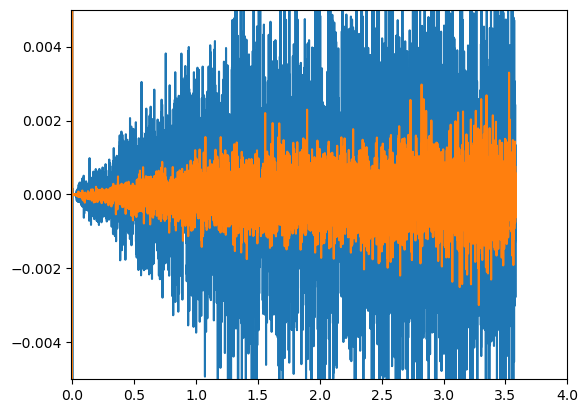

In [12]:
# check this
%matplotlib inline
print(len(allNaI_raw))
plt.plot(xs, sum_ch_raw[1]/np.sum(all_sequences))
plt.plot(xs, allNaI_raw/np.sum(all_sequences)/24)
plt.ylim(-0.005, 0.005)
plt.xlim(-0.01, 4.0)

In [13]:
fpl = 23.31
daq_delay = 0

m_n = 1.6749286*10**(-27)
# L = 0
J_to_eV = 6.24151*10**18
eV_to_J = 1.602176565*10**-19

def tof_to_eV(xtof, FPlength, t_off):
    m_n = 1.6749286*10**(-27)
    delay = t_off
    x_eV_out = 0.5*m_n*((FPlength/((xtof+delay)/1000)))**2*J_to_eV  ## tof in ms
    return x_eV_out
def eV_to_tof(xeV, FPlength, t_off):
    m_n = 1.6749286*10**(-27)
    delay = t_off
    x_tof_out = delay + 1000*FPlength*np.sqrt(m_n/(2*xeV*eV_to_J))  ## tof in ms
    return x_tof_out

In [14]:
print(tof_to_eV(0.780, fpl, daq_delay))
print(eV_to_tof(4.79, fpl, daq_delay))

4.668220001093984
0.7700208426295269


In [15]:
import sys

def sizeof_fmt(num, suffix='B'):
    ''' by Fred Cirera,  https://stackoverflow.com/a/1094933/1870254, modified'''
    for unit in ['','Ki','Mi','Gi','Ti','Pi','Ei','Zi']:
        if abs(num) < 1024.0:
            return "%3.1f %s%s" % (num, unit, suffix)
        num /= 1024.0
    return "%.1f %s%s" % (num, 'Yi', suffix)

for name, size in sorted(((name, sys.getsizeof(value)) for name, value in list(
                          locals().items())), key= lambda x: -x[1])[:10]:
    print("{:>30}: {:>8}".format(name, sizeof_fmt(size)))


                    all_raw_og: 766.6 MiB
                       all_raw: 694.6 MiB
                  all_raw_D_og: 398.7 MiB
                  all_raw_U_og: 398.7 MiB
                    sum_ch_raw:  1.7 MiB
                       all_amp: 83.9 KiB
                  all_integral: 83.9 KiB
                            xs: 70.4 KiB
            asym_raw_chdataset: 70.4 KiB
                         chraw: 70.4 KiB


In [16]:
# del all_raw_D ## might help with memory issues
# del all_raw_U
# del run_rawasym_D
# del run_rawasym_U
# del run_ampasym_D
# del run_ampasym_U
# del flatrunslist_D
# del flatrunslist_U
# del asym_raw_chdataset

In [17]:
def sizeof_fmt(num, suffix='B'):
    ''' by Fred Cirera,  https://stackoverflow.com/a/1094933/1870254, modified'''
    for unit in ['','Ki','Mi','Gi','Ti','Pi','Ei','Zi']:
        if abs(num) < 1024.0:
            return "%3.1f %s%s" % (num, unit, suffix)
        num /= 1024.0
    return "%.1f %s%s" % (num, 'Yi', suffix)

for name, size in sorted(((name, sys.getsizeof(value)) for name, value in list(
                          locals().items())), key= lambda x: -x[1])[:10]:
    print("{:>30}: {:>8}".format(name, sizeof_fmt(size)))

                    all_raw_og: 766.6 MiB
                       all_raw: 694.6 MiB
                  all_raw_D_og: 398.7 MiB
                  all_raw_U_og: 398.7 MiB
                    sum_ch_raw:  1.7 MiB
                       all_amp: 83.9 KiB
                  all_integral: 83.9 KiB
                            xs: 70.4 KiB
            asym_raw_chdataset: 70.4 KiB
                         chraw: 70.4 KiB


In [18]:

def loadrun_pulseadd(run, processedpath): ## not sure if this is the fastest way, or passing a list of runs...
    runname = processedpath+run
#     print(runname)
    with h5py.File(runname, 'r') as f:
        channels = list(f.keys())
        numchannels = len(channels)-1
        arrsizer = f[channels[-1]] ## gets the xs array
        arrsizer = np.asarray(arrsizer)
        numpoints = len(arrsizer)
#             num_seq = f.attrs.get('sequences')
#             numsequences.append(num_seq)
        rundat = np.zeros((numchannels,numpoints),dtype = np.float64)
#             print(str(np.char.zfill(str(chan_enab[i]),2)))
#             dataset = f['ch '+str(np.char.zfill(str(chan_enab[i]), 2))]
        for i in range(0,numchannels):
            dataset = f[channels[i]+'/added_pulses/'+channels[i]][:]  ##change this to match channels[i]
            chdata = np.array(dataset)
#                     print(chdata)
#                     print(np.size(chdata))
#                     print(len(chdata[0]))
#                     print(rundat)
            rundat[i] = rundat[i]+chdata
        f.close()
    return rundat

start=time.time()
# all_D = [] ## in this case cannot be np array because it is not same size arrays ## will be run, channel, numpoints
# all_D = np.zeros((numruns_tot_D, numchannels,numpoints),dtype = np.float64) ## run, channel, numpoints ## works if flatten the folders
# all_U = np.zeros((numruns_tot_U, numchannels,numpoints),dtype = np.float64) ## run, channel, numpoints ## works if flatten the folders
all_D = []
all_U = []

for f in range(0,len(folderslist)):
    fpath = root+processedfolder+folderslist[f]
    print(fpath)
    for r in range(0, len(runslist_D[f])):
        # print(runslist_D[f][r])
#         all_D.append(loadrun_pulseadd(runslist_D[f][r], fpath+'/pulseadd_D/'))
        # print(r)
#         all_D[r] = loadrun_pulseadd(runslist_D[f][r], fpath+'/pulseadd_D/')
#         all_U[r] = loadrun_pulseadd(runslist_U[f][r], fpath+'/pulseadd_U/')
        all_D.append(loadrun_pulseadd(runslist_D[f][r][:5]+'_pulseadd_D.h5', fpath+'/pulseadd_D/'))  ## added pulseadd str to this
        all_U.append(loadrun_pulseadd(runslist_U[f][r][:5]+'_pulseadd_U.h5', fpath+'/pulseadd_U/'))
#         print(all_D[r])
    print(fpath+' done')

all_D = np.asarray(all_D)
all_U = np.asarray(all_U)
    
print(all_D.shape)
all_D = np.asarray(all_D.transpose(1,0,2))  ## re-shape into ch, run, points
all_U = np.asarray(all_U.transpose(1,0,2))
print(all_D.shape)
    
end=time.time()
print('loaded pulseadd files time: ', end-start)

F:\LANL/processed_data/runs12686-13279/
F:\LANL/processed_data/runs12686-13279/ done
F:\LANL/processed_data/runs13280-13563/
F:\LANL/processed_data/runs13280-13563/ done
F:\LANL/processed_data/runs13564-13604/
F:\LANL/processed_data/runs13564-13604/ done
(447, 13, 8992)
(13, 447, 8992)
loaded pulseadd files time:  38.91770029067993


In [19]:
    memory_usage = sys.getsizeof(all_D)
    print(f"Memory usage of the list: {memory_usage} bytes")

    def sizeof_fmt(num, suffix='B'):
        ''' by Fred Cirera,  https://stackoverflow.com/a/1094933/1870254, modified'''
        for unit in ['','Ki','Mi','Gi','Ti','Pi','Ei','Zi']:
            if abs(num) < 1024.0:
                return "%3.1f %s%s" % (num, unit, suffix)
            num /= 1024.0
        return "%.1f %s%s" % (num, 'Yi', suffix)

    for name, size in sorted(((name, sys.getsizeof(value)) for name, value in list(
                              locals().items())), key= lambda x: -x[1])[:10]:
        print("{:>30}: {:>8}".format(name, sizeof_fmt(size)))

Memory usage of the list: 136 bytes
                    all_raw_og: 766.6 MiB
                       all_raw: 694.6 MiB
                  all_raw_D_og: 398.7 MiB
                  all_raw_U_og: 398.7 MiB
                    sum_ch_raw:  1.7 MiB
                       all_amp: 83.9 KiB
                  all_integral: 83.9 KiB
                            xs: 70.4 KiB
            asym_raw_chdataset: 70.4 KiB
                         chraw: 70.4 KiB


(13, 447, 8992)


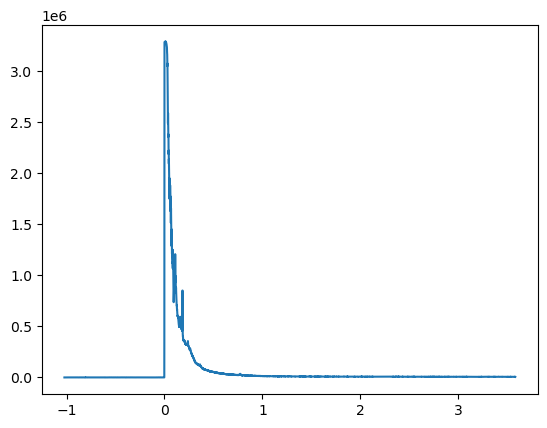

In [20]:
print(all_D.shape)
plt.plot(xs, all_D[1][20])

In [21]:
# print(round(len(flatrunslist_D)/5))
print(len(all_sequences))
print(len(all_amp[0]))
# print(len(np.sum(all_amp)))
print((np.where(all_sequences<=12)))
print(all_sequences[(np.where(all_sequences<=12))])
print(np.sum(all_sequences))
print(13*954)
# print(all_amp)


447
447
(array([446], dtype=int64),)
[6.]
5804.0
12402


In [22]:
# allNaI_raw = np.sum(sum_ch_raw[3:5], axis = 0)
# %matplotlib inline
# print(len(allNaI_raw))
# plt.plot(xs, sum_ch_raw[1]/np.sum(all_sequences))
# plt.plot(xs, allNaI_raw/np.sum(all_sequences)/24)
# plt.ylim(-0.005, 0.005)
# plt.xlim(-0.01, 4.0)

In [36]:
print(all_amp)
print(all_integral_D)

[[ 5.53686552e-01 -5.70492758e-01 -1.05380845e-01 ... -1.21412121e+00
  -9.14199383e-05  7.13446008e-02]
 [-1.10522725e+00  2.31125117e-01  3.09781059e-02 ... -5.13160591e-01
   1.11930666e+00 -2.07788786e-01]
 [ 3.33955012e-03  9.97892552e-01  5.75177299e-01 ...  2.00164913e+00
  -4.95640117e-01  4.64307173e-01]
 ...
 [ 9.51238466e-01  1.75083566e+00  8.02074722e-01 ...  1.74841031e+00
   8.67658715e-01 -5.72156534e-01]
 [-1.72216561e-01 -2.68941564e-01  1.17611767e+00 ...  8.86557367e-02
   7.78365548e-01  5.24316196e-02]
 [-1.91464074e-01  4.39758558e-01 -4.36549824e-01 ...  8.18672516e-01
   4.72374848e-01  4.18343002e-01]]
[[ 0.627523    0.57633333 -0.83097955 ... -1.22536858 -0.03577379
   0.2791451 ]
 [-1.33454064 -0.02970296 -0.23925534 ... -1.00926588  0.97504257
  -0.1548932 ]
 [-0.23604806  0.57040781  0.75763093 ...  1.81133859 -0.69110731
   0.48439559]
 ...
 [ 0.70562815  1.54041755  1.31781664 ...  0.60468749  0.0586518
  -0.2989468 ]
 [-0.61785209  0.16897216  0.7568158

In [24]:
# print(np.array(all_raw).shape)
# # print(np.where(all_raw[0][:][:]<= 5))
# p1 = 0
# p2 = 150
# for i in range(p1,p2):
#     plt.plot(all_raw[3][i])

# plt.xlim(2200,9000)
# plt.ylim(-10, 10)
# # plt.show()

In [25]:
# print(np.mean(all_amp[1]))
# # print(all_amp.shape)
# # print(all_sequences)

# # Create sample arrays
# array1 = all_sequences
# array2 = all_amp

# # Save the arrays to an uncompressed .npz file
# np.savez('asym_all_detectors_Pr.npz', arr1=array1, arr2=array2)

In [37]:
## from chat
D, R = all_amp.shape

# Weighted mean per detector
w_mean_det_amp = np.sum(all_amp * all_sequences, axis=1) / np.sum(all_sequences)
w_mean_det_integral = np.sum(all_integral * all_sequences, axis=1) / np.sum(all_sequences)

# Weighted standard deviation per detector
w_var_det_amp = np.sum(all_sequences * (all_amp - w_mean_det_amp[:, None])**2, axis=1) / np.sum(all_sequences)
w_std_det_amp = np.sqrt(w_var_det_amp)
stderr_det_amp = w_std_det_amp / np.sqrt(len(all_sequences))
print(w_mean_det_amp.shape, stderr_det_amp.shape)

w_var_det_integral = np.sum(all_sequences * (all_integral - w_mean_det_integral[:, None])**2, axis=1) / np.sum(all_sequences)
w_std_det_integral = np.sqrt(w_var_det_integral)
stderr_det_integral = w_std_det_integral / np.sqrt(len(all_sequences))
print(w_mean_det_integral.shape, stderr_det_integral.shape)

# Combined weighted mean (all detectors)
w_mean_all_amp = np.sum(all_amp * all_sequences) / np.sum(all_sequences)
w_var_all_amp = np.sum(all_sequences * (all_amp - w_mean_all_amp)**2) / np.sum(all_sequences)
w_std_all_amp = np.sqrt(w_var_all_amp)
stderr_all_amp = w_std_all_amp / np.sqrt(all_amp.size)

w_mean_all_integral = np.sum(all_integral * all_sequences) / np.sum(all_sequences)
w_var_all_integral = np.sum(all_sequences * (all_integral - w_mean_all_integral)**2) / np.sum(all_sequences)
w_std_all_integral = np.sqrt(w_var_all_integral)
stderr_all_integral = w_std_all_integral / np.sqrt(all_integral.size)

print(f"Weighted mean per detector: {w_mean_det_amp}")
print(f"Combined asymmetry (all 24 dets): {w_mean_all_amp:.6f} ± {stderr_all_amp:.6f}")
print(w_mean_det_amp.shape, stderr_det_amp.shape)
print(w_mean_all_amp.shape, stderr_all_amp.shape)

print(f"Weighted mean per detector: {w_mean_det_integral}")
print(f"Combined asymmetry (all 24 dets): {w_mean_all_integral:.6f} ± {stderr_all_integral:.6f}")
print(w_mean_det_integral.shape, stderr_det_integral.shape)
print(w_mean_all_integral.shape, stderr_all_integral.shape)


(24,) (24,)
(24,) (24,)
Weighted mean per detector: [-1.53446279e-01 -3.44495271e-02 -5.71865018e-02 -8.44007981e-02
 -6.84553619e-02  2.96474908e-02  1.12437825e-02 -1.18509020e-02
  5.78093672e-02  1.54772384e-02  5.01215249e-03 -9.63676502e-03
 -4.08165724e-02  2.18765328e-02 -8.33363647e-04  1.05462342e-02
 -2.12956034e-02  2.13339868e-03  2.67872730e+00 -5.34659292e-03
 -5.77613823e-03  3.43513486e-02  3.85581980e-02  4.24220798e-02]
Combined asymmetry (all 24 dets): 2.454311 ± 0.572027
(24,) (24,)
() ()
Weighted mean per detector: [-1.17569731e-01 -5.22588474e-02 -4.92999471e-02 -1.70761432e-01
 -5.62276666e-02  5.99751692e-02  3.13577310e+00  3.22063025e-02
  5.10556147e-02  8.40349373e-02 -9.99568073e-03  1.90138061e-02
 -3.68112458e-02  3.08508247e-02  9.55199266e-03  3.03101146e-02
 -1.27937404e-02  1.22881891e-03 -1.99458285e+00 -1.74245138e-02
  1.89089553e-02  1.46444404e-01  3.71575067e-02  2.98389344e-02]
Combined asymmetry (all 24 dets): 1.168625 ± 0.801759
(24,) (24,)


In [38]:
print(stderr_det_amp)

[0.10545225 0.02974164 0.03214846 0.0553548  0.03346543 0.0526403
 0.0893813  0.03849804 0.03168386 0.06388664 0.03626376 0.03254608
 0.04157624 0.0231996  0.02345093 0.04468422 0.02826651 0.02487542
 2.73675741 0.02892975 0.02932899 0.06548304 0.03009406 0.02507342]


In [39]:
print("all_amp shape:", all_amp.shape)
print("all_sequences shape:", all_sequences.shape)
print("min/max of all_amp (per-seq):", np.min(all_amp), np.max(all_amp), np.mean(all_amp))
print("min/max of all_amp_norm (for hist):", np.min(all_amp/all_sequences[None,:]), np.max(all_amp/all_sequences[None,:]))
print("sum(all_amp * n) / sum(n)  (WHAT YOU COMPUTED) =", np.sum(all_amp * all_sequences[None,:]) / np.sum(all_sequences))
print("Divide that by D (correct):", np.sum(all_amp * all_sequences[None,:]) / (D * np.sum(all_sequences)))


all_amp shape: (24, 447)
all_sequences shape: (447,)
min/max of all_amp (per-seq): -41.6455841588181 1223.7268017065196 0.10223549385777955
min/max of all_amp_norm (for hist): -3.2035064737552386 94.1328309005015
sum(all_amp * n) / sum(n)  (WHAT YOU COMPUTED) = 2.454310712955888
Divide that by D (correct): 0.10226294637316201


In [40]:
# def w_asym(asym_array, sequences):
#         # Handle single detector case by reshaping
#     if asym_array.ndim == 1:
#         asym_array = asym_array[None, :]
#     D, R = asym_array.shape
#     mu = np.sum(asym_array * sequences[None, :]) / (D * np.sum(sequences)) # mean 
#     resid = asym_array - mu
#     S = np.sum(sequences[None, :] * resid**2)
#     sigma2 = S / (D * R - 1)
#     stderr = np.sqrt(sigma2 / (D * np.sum(sequences)))
#     return mu, stderr



# mean_all, se_all = w_asym(all_amp, all_sequences)
# # mean_corner, se_corner = w_asym(all_amp[corner_idx], all_sequences)
# # mean_noncorner, se_noncorner = w_asym(all_amp[noncorner_idx], all_sequences)
# print(mean_all, se_all)

# ch = 14
# w_mean_det_amp2, stderr_det_amp2 = w_asym(all_amp[ch], all_sequences)
# print(w_mean_det_amp2.shape, stderr_det_amp2.shape)
# print(w_mean_det_amp2, stderr_det_amp2)

In [41]:
def weighted_asymmetry(asym_array, sequences):
    if asym_array.ndim == 1:
        total_weight = np.sum(sequences)
        mu = np.sum(asym_array * sequences) / total_weight
        resid = asym_array - mu
        S = np.sum(sequences * resid**2)
        sigma2 = S / total_weight          # <— match old code
        stderr = np.sqrt(sigma2 / len(sequences))
    else:
        D, R = asym_array.shape
        total_weight = D * np.sum(sequences)
        mu = np.sum(asym_array * sequences[None, :]) / total_weight
        resid = asym_array - mu
        S = np.sum(sequences[None, :] * resid**2)
        sigma2 = S / total_weight          # <— match old code
        stderr = np.sqrt(sigma2 / (D * R))
    return mu, stderr


In [42]:
def w_asym(asym_array, sequences):
    # Check if multiple detectors or not
    single_channel = False
    if asym_array.ndim == 1:
        single_channel = True
        asym_array = asym_array[None, :]  # shape (1, R)
    ## definitions for clarity
    D, R = asym_array.shape  # number of detectors, runs
    N_r = sequences              # sequences per run
    N_seq = np.sum(N_r)          # total sequences per detector
    N_tot = D * N_seq            # total measurements across all detectors

    # weighted mean per det
    weighted_sum = np.sum(asym_array * N_r[None, :], axis=1)  # shape (D,)
    mu_det = weighted_sum / N_seq
    # SE per detector
    resid = asym_array - mu_det[:, None]
    S_d = np.sum(N_r[None, :] * resid**2, axis=1) #weighted sum of residuals
    sigma2_d = S_d / N_seq
    se_det = np.sqrt(sigma2_d / N_seq)

    if single_channel==True:  ## end here for 1 channel
        return mu_det[0], se_det[0]

    # if D>1, find the final weighted asym +/- error
    mu_total = np.sum(weighted_sum) / N_tot
    resid_total = asym_array - mu_total
    S_total = np.sum(N_r[None, :] * resid_total**2)
    sigma2_total = S_total / N_tot
    se_total = np.sqrt(sigma2_total / N_tot)
    if single_channel==False:
        return mu_total, se_total
        # return mu_det, se_det, mu_total, se_total  #if channels and totals are wanted. I find it a little confusing this way. 


w_mean_det_amp_new, stderr_det_amp_new = [], []
for ch in range(0, all_amp.shape[0]):  # each detector
    mu_ch, se_ch = w_asym(all_amp[ch], all_sequences)
    w_mean_det_amp_new.append(mu_ch)
    stderr_det_amp_new.append(se_ch)

w_mean_det_amp_new = np.array(w_mean_det_amp_new)
stderr_det_amp_new = np.array(stderr_det_amp_new)

mean_all, se_all = w_asym(all_amp, all_sequences)
# mean_corner, se_corner = w_asym(all_amp[corner_idx], all_sequences)
# mean_noncorner, se_noncorner = w_asym(all_amp[noncorner_idx], all_sequences)
print(mean_all, se_all)
print(w_mean_all_amp/24, stderr_all_amp)  #std err all amp not the same i guess

ch = 4
w_mean_det_amp2, stderr_det_amp2 = w_asym(all_amp[ch], all_sequences)
print(w_mean_det_amp2.shape, stderr_det_amp2.shape)
print(w_mean_det_amp2, stderr_det_amp2)
print()
print(w_mean_det_amp_new[ch], stderr_det_amp_new[ch])

0.10226294637316204 0.03178544803596137
0.10226294637316201 0.5720267474332059
() ()
-0.06845536193716877 0.009287235127559381

-0.06845536193716877 0.009287235127559381


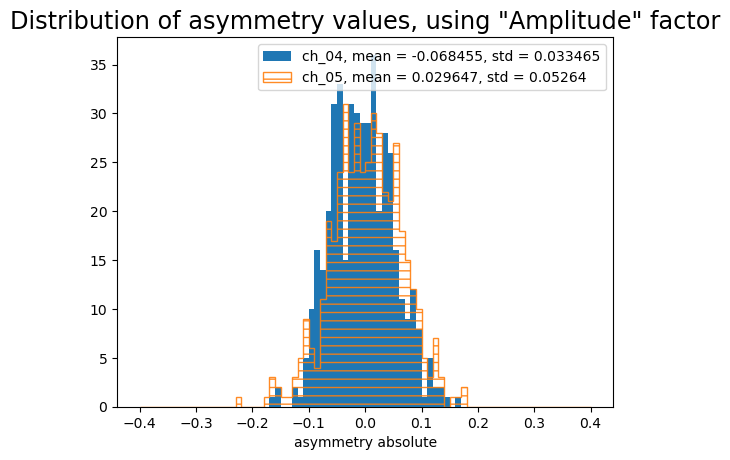

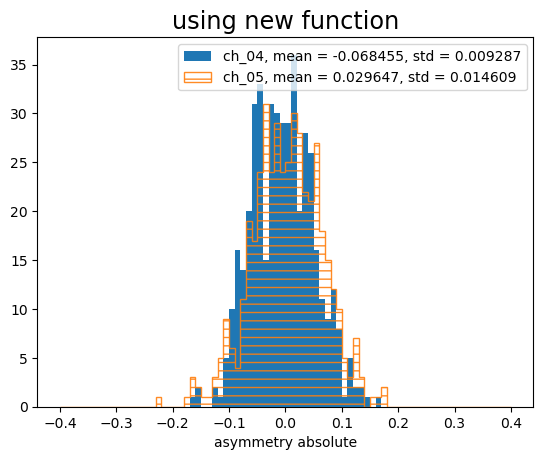

In [43]:
%matplotlib inline
all_amp_norm = all_amp/(all_sequences) # just for hists, not for weighted avg

ch = 4
bval = 80
r = [-0.4,0.4]
# factor = all_sequences[ch]
plt.figure()
plt.title(rf'Distribution of asymmetry values, using "Amplitude" factor', fontsize = 'xx-large')
mean = np.round(w_mean_det_amp[ch],6)
# std = np.round(np.std(all_amp_norm[ch]),6)
std = np.round(stderr_det_amp[ch],6)
mean2 = np.round((w_mean_det_amp[ch+1]),6)
# std2 = np.round(np.std(all_amp_norm[ch+1]),6)
std2 = np.round((stderr_det_amp[ch+1]),6)
plt.hist(all_amp_norm[ch], bins =bval, range = r,  label = channels_all[ch]+f', mean = {mean}, std = {std}')  ## all runs, ch, parameters array, sigma value
# plt.figure()
plt.hist(all_amp_norm[ch+1], bins =bval, range = r, alpha =0.9, hatch='--',histtype='step', label = channels_all[ch+1]+f', mean = {mean2}, std = {std2}')  ## all runs, ch, parameters array, sigma value
plt.xlabel('asymmetry absolute')
plt.legend(fontsize = 'medium')
plt.show()

plt.figure()
plt.title(rf'using new function', fontsize = 'xx-large')
mean = np.round(w_mean_det_amp_new[ch],6)
# std = np.round(np.std(all_amp_new_norm[ch]),6)
std = np.round(stderr_det_amp_new[ch],6)
mean2 = np.round((w_mean_det_amp_new[ch+1]),6)
# std2 = np.round(np.std(all_amp_new_norm[ch+1]),6)
std2 = np.round((stderr_det_amp_new[ch+1]),6)
plt.hist(all_amp_norm[ch], bins =bval, range = r,  label = channels_all[ch]+f', mean = {mean}, std = {std}')  ## all runs, ch, parameters array, sigma value
# plt.figure()
plt.hist(all_amp_norm[ch+1], bins =bval, range = r, alpha =0.9, hatch='--',histtype='step', label = channels_all[ch+1]+f', mean = {mean2}, std = {std2}')  ## all runs, ch, parameters array, sigma value
plt.xlabel('asymmetry absolute')
plt.legend(fontsize = 'medium')
plt.show()

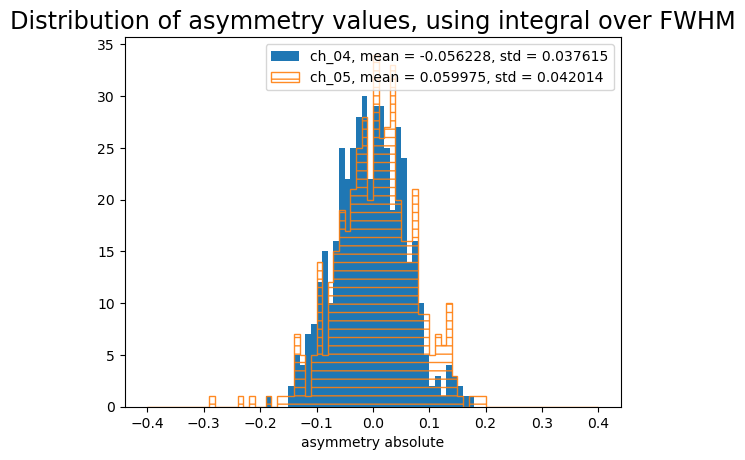

In [44]:
%matplotlib inline
all_integral_norm = all_integral/(all_sequences) # just for hists, not for weighted avg

# ch = 4
bval = 80
r = [-0.4,0.4]
# factor = all_sequences[ch]
plt.title(rf'Distribution of asymmetry values, using integral over FWHM', fontsize = 'xx-large')
mean = np.round(w_mean_det_integral[ch],6)
# std = np.round(np.std(all_integral_norm[ch]),6)
std = np.round(stderr_det_integral[ch],6)
mean2 = np.round((w_mean_det_integral[ch+1]),6)
# std2 = np.round(np.std(all_integral_norm[ch+1]),6)
std2 = np.round((stderr_det_integral[ch+1]),6)
plt.hist(all_integral_norm[ch], bins =bval, range = r,  label = channels_all[ch]+f', mean = {mean}, std = {std}')  ## all runs, ch, parameters array, sigma value
# plt.figure()
plt.hist(all_integral_norm[ch+1], bins =bval, range = r, alpha =0.9, hatch='--',histtype='step', label = channels_all[ch+1]+f', mean = {mean2}, std = {std2}')  ## all runs, ch, parameters array, sigma value
plt.xlabel('asymmetry absolute')
plt.legend(fontsize = 'medium')
plt.show()

In [45]:
# amp_integral_means = [[],[]]
# amp_integral_stds = [[],[]]

# for ch in range(0, len(all_amp)):
#     mamp = np.mean(all_amp_norm[ch])
#     samp = np.std(all_amp_norm[ch])
#     mint = np.mean(all_integral_norm[ch])
#     sint = np.std(all_integral_norm[ch])
#     amp_integral_means[0].append(mamp)
#     amp_integral_stds[0].append(samp)
#     amp_integral_means[1].append(mint)
#     amp_integral_stds[1].append(sint)

# amp_integral_means = np.asarray(amp_integral_means)
# amp_integral_stds = np.asarray(amp_integral_stds)
# mean_diffs = amp_integral_means[0]-amp_integral_means[1]
# # print(amp_integral_means[0])

# # print(amp_integral_means)

# df1 = pd.DataFrame(amp_integral_means)
# print(df1)
# print(mean_diffs)

TypeError: len() takes exactly one argument (0 given)

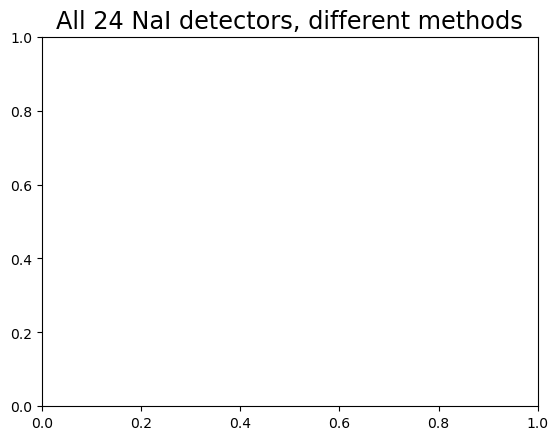

In [46]:
## all 24, amplitude / integral

%matplotlib inline
r = [-0.40,0.40]
b = 100

all_NaI_amp = all_amp_norm.flatten()

plt.title(rf'All 24 NaI detectors, different methods', fontsize = 'xx-large')
mean = np.round(w_mean_all_amp/len(),6)
std = np.round(stderr_all_amp,6)

# label = f'Amplitude method\nmean = {mean}, (std/ $\\sqrt{{N_R*N_D}}$) = {std}'
n_amp, bins_amp, patches_amp = plt.hist(all_NaI_amp,bins=b,range=r, label = f'Amplitude method\nmean = {mean}, (std/ $\\sqrt{{N_R*N_D}}$) = {std}')
print(mean)
print(np.mean(sum_ch_amp))

all_NaI_integral = all_integral_norm.flatten()
mean2 = np.round(w_mean_all_integral/len(),6)
std2 = np.round(stderr_all_integral,6)

n_int, bins_int, patches_int = plt.hist(all_NaI_integral,bins=b,range=r, label = f'Integral method\nmean = {mean2}, (std/ $\\sqrt{{N_R*N_D}}$) = = {std2}', alpha =0.9, hatch='--',histtype='step')

def gauss(x,amp,mu,sigma): # deinition of function
    return amp*np.exp(-(x-mu)**2/2*sigma**2)

y_amp = n_amp
y_int = n_int
x = np.linspace(r[0],r[1], b)

popt_amp,pcov_amp=curve_fit(gauss,x,y_amp,p0=[100,0,2]) # popt= optimize parameter
plt.plot(x,gauss(x,*popt_amp),color='blue',lw=2.0,ls = '--',label=f'Amplitude Gaussian fit mean={np.round(popt_amp[0],5)}, mu={np.round(popt_amp[1],5)}')
popt_int,pcov_int=curve_fit(gauss,x,y_int,p0=[100,0,2]) # popt= optimize parameter
plt.plot(x,gauss(x,*popt_int),color='orange',lw=2.0,ls = '--',label=f'Integral Gaussian fit mean={np.round(popt_int[0],5)}, mu={np.round(popt_int[1],5)}')
# print('amp',popt[0]) # amp
# print('meam',popt[1])# mean mu
# print('sigma',popt[2]) # sigma


plt.xlabel('asymmetry absolute')
plt.legend()
plt.show()
print(mean2)
# print(np.mean(sum_ch_integral))


In [47]:
## general function for reduced chi square for a given fit function. sigma is important to estimate.

def chi_square_dof(fit_func, xdata, ydata, popt, sigma=None):
    """
    Calculate chi-square and degrees of freedom for a fit.

    Parameters:
        fit_func : callable
            The model function, f(x, ...).
        xdata : array_like
            The independent variable where the data is measured.
        ydata : array_like
            The dependent data — measured values.
        popt : array_like
            Optimal values for the parameters from curve_fit.
        sigma : array_like or None
            Standard deviation errors of ydata. If None, equal weights assumed.

    Returns:
        chi2 : float
            Chi-square statistic.
        dof : int
            Degrees of freedom.
        reduced_chi2 : float
            Reduced chi-square (chi2 / dof)
    """
    yfit = fit_func(xdata, *popt)
    residuals = ydata - yfit
    if sigma is None:
        chi2 = np.sum(residuals**2)
    else:
        chi2 = np.sum((residuals / sigma)**2)
    dof = len(ydata) - len(popt)
    reduced_chi2 = chi2 / (dof)
    return residuals, chi2, dof, reduced_chi2

def gauss(x,amp,mu,sigma): # deinition of function
    return amp*np.exp(-(x-mu)**2/2*sigma**2)

In [48]:
## all 24, amplitude / integral
## redo with chisquare for gaussian fit

%matplotlib qt
r = [-0.30,0.30]
b = 100

all_NaI_amp = all_amp_norm.flatten()
# all_NaI_amp = np.sum(all_amp_norm, axis = 0)
# print(len(testsum))
plt.title(rf'All 24 NaI detectors, different methods', fontsize = 'xx-large')
mean = np.round(np.mean(all_NaI_amp),6)
std = np.round(np.std(all_NaI_amp)/(np.sqrt(numruns_tot_D*24)),6)
n_amp, bins_amp, patches_amp = plt.hist(all_NaI_amp,bins=b,range=r, label = f'Amplitude method\nmean = {mean}, (std/ $\sqrt{{N_R*N_D}}$) = {std}')
print(mean)
print(np.mean(sum_ch_amp))

all_NaI_integral = all_integral_norm.flatten()
# all_NaI_integral = np.sum(all_integral_norm, axis = 0)
# print(len(testsum))
# plt.title(rf'maybe all 24 detectors using integral over FWHM', fontsize = 'xx-large')
mean2 = np.round(np.mean(all_NaI_integral),6)
std2 = np.round(np.std(all_NaI_integral)/(np.sqrt(numruns_tot_D*24)),6)

n_int, bins_int, patches_int = plt.hist(all_NaI_integral,bins=b,range=r, label = f'Integral method\nmean = {mean2}, std = {std2}', alpha =0.9, hatch='--',histtype='step')

y_amp = n_amp
y_int = n_int
x = np.linspace(r[0],r[1], b)

popt_amp,pcov_amp=curve_fit(gauss,x,y_amp,p0=[100,0,2]) # popt= optimize parameter
# s_test = np.ones(len(y_amp))*15
# s_test = np.ones(len(y_amp))*np.mean(np.abs(chi2_amp[0]))
# s_test = np.ones(len(y_amp))*np.std(all_NaI_amp)
s_test = np.sqrt(y_amp)
s_test[s_test == 0] = 1
# print(np.std(all_NaI_amp))

# print(np.sqrt(numruns_tot_D*24))
# print(s_test)
chi2_amp = chi_square_dof(gauss,x,y_amp, popt_amp, s_test)
# print(np.mean(np.abs(chi2_amp[0])))
print('chi square/dof for amp: ', chi2_amp[-1])
# plt.plot(x,gauss(x,*popt_amp),color='blue',lw=2.0,ls = '--',label=f'Amplitude Gaussian fit mu={np.round(popt_amp[1],5)}, $\chi$/dof={np.round(chi2_amp[-1],4)}')
plt.plot(x,gauss(x,*popt_amp),color='blue',lw=2.0,ls = '--',label=f'Amplitude Gaussian fit mu={np.round(popt_amp[1],5)}')

popt_int,pcov_int=curve_fit(gauss,x,y_int,p0=[100,0,2]) # popt= optimize parameter

s_test = np.sqrt(y_int)
s_test[s_test == 0] = 1
chi2_int = chi_square_dof(gauss,x,y_int, popt_int, s_test)
# print(np.mean(np.abs(chi2_int[0])))
print('chi square/dof for int: ', chi2_int[-1])
# plt.plot(x,gauss(x,*popt_int),color='orange',lw=2.0,ls = '--',label=f'Integral Gaussian fit mu={np.round(popt_int[1],5)}, $\chi$/dof={np.round(chi2_int[-1],4)}')
plt.plot(x,gauss(x,*popt_int),color='orange',lw=2.0,ls = '--',label=f'Integral Gaussian fit mu={np.round(popt_int[1],5)}')

# print('amp',popt[0]) # amp
# print('meam',popt[1])# mean mu
# print('sigma',popt[2]) # sigma


plt.xlabel('asymmetry absolute')
plt.legend()
plt.show()
print(mean2)
# print(np.mean(sum_ch_integral))


0.00788
0.007873753575883434
chi square/dof for amp:  2.6783191320419837
chi square/dof for int:  3.4736654458123892
0.003783


In [50]:
print(np.sqrt(y_amp))

[ 1.          1.          0.          1.41421356  1.41421356  1.
  1.          1.41421356  1.73205081  1.41421356  1.          0.
  2.64575131  1.41421356  2.23606798  1.          2.64575131  3.
  3.          2.64575131  2.82842712  3.60555128  4.24264069  4.69041576
  4.89897949  4.69041576  3.74165739  5.65685425  6.40312424  7.28010989
  8.60232527  8.1240384   9.          9.89949494 10.34408043 12.04159458
 11.74734012 12.40967365 13.3041347  15.65247584 17.2626765  17.29161647
 18.05547009 18.08314132 19.13112647 19.94993734 20.51828453 21.26029163
 21.14237451 21.28379665 20.90454496 22.04540769 21.44761059 20.54263858
 20.34698995 18.94729532 18.94729532 17.69180601 16.73320053 15.62049935
 15.62049935 13.60147051 12.92284798 11.66190379 11.09053651 11.
  9.05538514  8.60232527  7.41619849  7.54983444  7.07106781  5.83095189
  4.89897949  5.38516481  5.38516481  5.29150262  4.12310563  3.87298335
  2.44948974  3.16227766  2.44948974  2.82842712  2.44948974  2.82842712
  2.449489

5364 5364


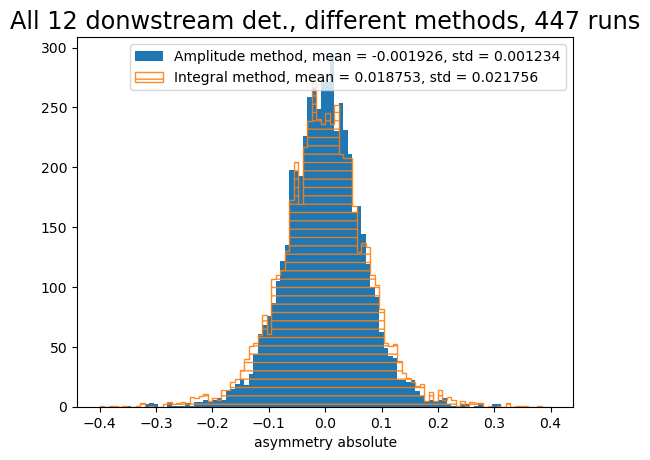

5364


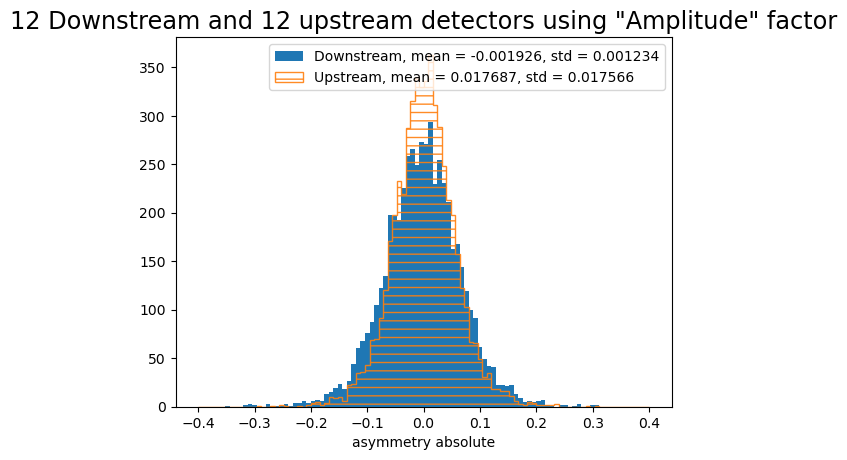

In [51]:
## upstream / downstream 

%matplotlib inline
r = [-0.4,0.4]
b = 100
all_amp_norm_D = (all_amp_D/all_sequences).flatten()
all_integral_norm_D = (all_integral_D/all_sequences).flatten()
print(len(all_amp_norm_D), len(all_integral_norm_D))
mean = np.round(np.mean(all_amp_norm_D),6)
std = np.round(np.std(all_amp_norm_D)/(np.sqrt(numruns_tot_D*12)),6)
mean2 = np.round(np.mean(all_integral_norm_D),6)
std2 = np.round(np.std(all_integral_norm_D)/(np.sqrt(numruns_tot_D*12)),6)

plt.hist(all_amp_norm_D, bins=b,range=r, label = f'Amplitude method, mean = {mean}, std = {std}')
plt.hist(all_integral_norm_D, bins=b,range=r, label = f'Integral method, mean = {mean2}, std = {std2}', alpha =0.9, hatch='--',histtype='step')
# plt.figure()
# plt.hist(all_integral_norm[ch+1], bins =bval, range = r, alpha =0.9, hatch='--',histtype='step', label = channels_all[ch+1]+f', mean = {mean2}, (plain) std = {std2}')  ## all runs, ch, parameters array, sigma value
plt.title(f'All 12 donwstream det., different methods, {numruns_tot_D} runs', fontsize = 'xx-large')
plt.xlabel('asymmetry absolute')
plt.legend(fontsize = 'medium')
plt.show()

plt.figure()
all_amp_norm_U = (all_amp_U/all_sequences).flatten()
print(len(all_amp_norm_U))
mean_U = np.round(np.mean(all_amp_norm_U),6)
# std = np.round(np.std(all_amp_norm_U),6)
std_U = np.round(np.std(all_amp_norm_U)/(np.sqrt(numruns_tot_U*12)),6)

# plt.hist(all_amp_norm_U, bins = b, range=r, label = rf'mean = {mean}, std = {std}')
plt.hist(all_amp_norm_D, bins=b,range=r, label = f'Downstream, mean = {mean}, std = {std}')
plt.hist(all_amp_norm_U, bins=b,range=r, label = f'Upstream, mean = {mean_U}, std = {std_U}', alpha =0.9, hatch='--',histtype='step')

plt.title(rf'12 Downstream and 12 upstream detectors using "Amplitude" factor', fontsize = 'xx-large')
plt.xlabel('asymmetry absolute')
plt.legend()
plt.show()

In [52]:
# print(all_amp_norm.shape)
# print(all_amp_norm[6][50:60])

# print(all_amp_norm[[0,3,6,9,12,15,18,21]][50:60])

corners = [0,3,6,9,12,15,18,21]
corner_amp_norm = np.asarray(all_amp_norm[corners])
# print(corner_amp_norm.shape)
print(all_amp_norm.shape)
print(np.delete(all_amp_norm[:],7))
print(np.delete(all_amp_norm[::],7).shape)
# print(corner_amp_norm[2][50:60])
print(all_amp_norm[:,7])

for i in range(0,24):
    # print(np.mean(all_amp_norm[i]))
    z = np.abs(stats.zscore((all_amp_norm[i])))
    # print(z)
    threshold_z = 15
    outlier_indices = np.where(z > threshold_z)[0]
    print(outlier_indices)

print(np.min(all_amp_norm[18]))

%matplotlib qt
plt.hist(all_amp_norm[18],bins=b,range=[-0.5,0.5], label = rf'Corner, mean = {mean}, plain std = {std}')
print(np.mean(all_amp_norm[18]))
print(np.std(np.delete(all_amp_norm[18],7)))

(24, 447)
[ 0.04259127 -0.04388406 -0.00810622 ...  0.06297481  0.03633653
  0.06972383]
(10727,)
[ 1.72077952e-01 -9.64309280e-03 -3.16447632e-01 -2.98861643e-01
 -1.52788439e-01  8.67919184e-01  5.74994130e-01  2.77275996e-01
  3.91866184e-02  2.78636392e-02 -6.42115496e-02  2.75511642e-02
 -1.15469681e-01  3.36181723e-02 -3.05927142e-02 -6.04406380e-02
 -6.63043955e-02  4.48612836e-02  9.41328309e+01  1.15756230e-01
  6.04633307e-02 -4.43538318e-02  4.88742699e-02 -1.92255405e-01]


NameError: name 'stats' is not defined

In [53]:
from scipy import stats
ch = 7
z = np.abs(stats.zscore(all_amp_norm[ch]))
# print(z)

threshold_z = 20

outlier_indices = np.where(z > threshold_z)[0]
print()
print(outlier_indices)
print(all_amp_norm[ch][105:115])
print(np.delete(all_amp_norm[ch], 7)[105:115])
print(all_amp_norm[ch][outlier_indices])
# no_outliers = df_diabetics.drop(outlier_indices)
# print("Original DataFrame Shape:", df_diabetics.shape)
# print("DataFrame Shape after Removing Outliers:", no_outliers.shape)


[]
[-0.00051946  0.02002275  0.01300041 -0.03327561  0.30638012 -0.02628465
  0.10813987 -0.00652395 -0.02734989  0.04759738]
[ 0.02002275  0.01300041 -0.03327561  0.30638012 -0.02628465  0.10813987
 -0.00652395 -0.02734989  0.04759738  0.00970924]
[]


In [55]:
## corner v noncorner
%matplotlib qt
r = [-0.5,0.5]
b = 100

print(len(all_amp_norm))
# corners = [0,3,6,9] ## downstream (?)
corners = [0,3,6,9,12,15,18,21]
corner_amp_norm = np.asarray(all_amp_norm[corners]).flatten()
print(all_amp_norm[corners].shape, (corner_amp_norm.shape))
mean = np.round(np.mean(corner_amp_norm),7)
std = np.round(np.std(corner_amp_norm)/(np.sqrt(numruns_tot_D*len(corners))),7) ## len of corner_amp_norm = numruns*8 (8 corner)
# std = np.round(np.std(corner_amp_norm)/(np.sqrt(len(corner_amp_norm))),6) ## len of corner_amp_norm = numruns*8 (8 corner)

plt.hist(corner_amp_norm,bins=b,range=r, label = rf'Corner, mean = {mean}, plain std = {std}')

# # noncorners = [1,2,4,5,7,8,10,11] ## downstream (?)
# noncorners = [1,2,4,5,7,8,10,11,13,14,16,17,19,20,22,23]
# noncorner_amp_norm = np.asarray(all_amp_norm[noncorners]).flatten()
# print(all_amp_norm[noncorners].shape, (noncorner_amp_norm.shape))
# # noncorner_amp_norm = noncorner_amp_norm[0].flatten()
# print(len(noncorner_amp_norm))
# mean2 = np.round(np.mean(noncorner_amp_norm),7)
# std2 = np.round(np.std(noncorner_amp_norm)/(np.sqrt(numruns_tot_D*len(noncorners))),7) 
# # std2 = np.round(np.std(noncorner_amp_norm)/(np.sqrt(len(noncorner_amp_norm))),6) 

# plt.hist(noncorner_amp_norm,bins=b,range=r, label = rf'Non-corner, mean = {mean2}, plain std = {std2}', alpha =0.9, hatch='--',histtype='step')

plt.title(rf'Corner v. Non-corner detectors', fontsize = 'xx-large')
plt.xlabel('asymmetry absolute')
plt.legend()
plt.show()

24
(8, 447) (3576,)


24
(8, 447) (3576,)
(8, 447) (3576,)
3576


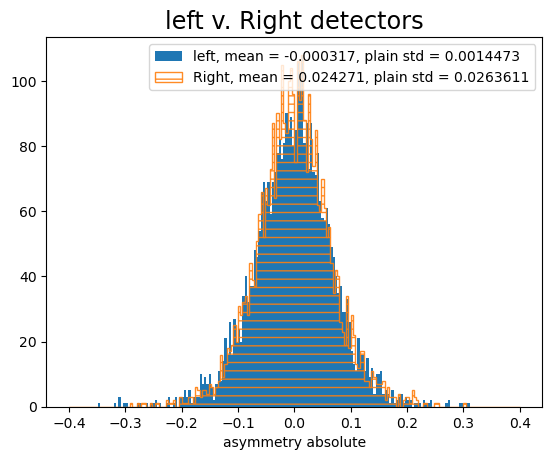

In [56]:
##left v right
## facing downstream towards beam-dump

%matplotlib inline
r = [-0.4,0.4]
b = 200

print(len(all_amp_norm))
# left = [0,3,6,9] ## downstream (?)
left = [3,4,5,6,12,23,22,21]
left_amp_norm = np.asarray(all_amp_norm[left]).flatten()
print(all_amp_norm[left].shape, (left_amp_norm.shape))
mean = np.round(np.mean(left_amp_norm),6)
std = np.round(np.std(left_amp_norm)/(np.sqrt(numruns_tot_D*8)),7) ## len of left_amp_norm = numruns*8 (8 left)
# std = np.round(np.std(left_amp_norm)/(np.sqrt(len(left_amp_norm))),6) ## len of left_amp_norm = numruns*8 (8 left)

plt.hist(left_amp_norm,bins=b,range=r, label = rf'left, mean = {mean}, plain std = {std}')

# right = [1,2,4,5,7,8,10,11] ## downstream (?)
right = [0,11,10,9,15,16,17,18]
right_amp_norm = np.asarray(all_amp_norm[right]).flatten()
print(all_amp_norm[right].shape, (right_amp_norm.shape))
# right_amp_norm = right_amp_norm[0].flatten()
print(len(right_amp_norm))
mean2 = np.round(np.mean(right_amp_norm),6)
std2 = np.round(np.std(right_amp_norm)/(np.sqrt(numruns_tot_D*8)),7) 
# std2 = np.round(np.std(right_amp_norm)/(np.sqrt(len(right_amp_norm))),6) 

plt.hist(right_amp_norm,bins=b,range=r, label = rf'Right, mean = {mean2}, plain std = {std2}', alpha =0.9, hatch='--',histtype='step')

plt.title(rf'left v. Right detectors', fontsize = 'xx-large')
plt.xlabel('asymmetry absolute')
plt.legend()
plt.show()

24
(8, 447) (3576,)
(8, 447) (3576,)
3576


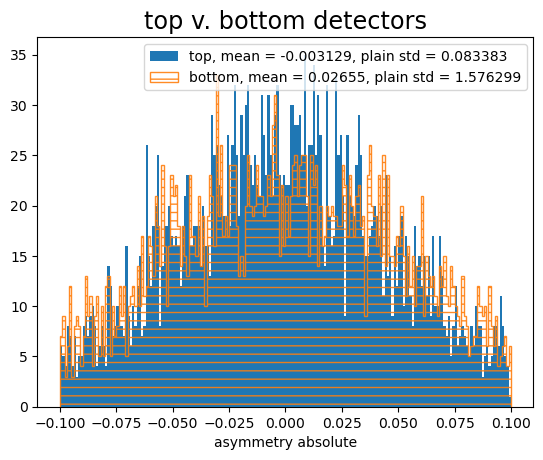

In [57]:
##top v bottom

%matplotlib inline
r = [-0.1,0.1]
b = 200

print(len(all_amp_norm))
# top = [0,3,6,9] ## downstream (?)
top = [0,1,2,3,12,13,14,15]
top_amp_norm = np.asarray(all_amp_norm[top]).flatten()
print(all_amp_norm[top].shape, (top_amp_norm.shape))
mean = np.round(np.mean(top_amp_norm),6)
std = np.round(np.std(top_amp_norm),6) ## len of top_amp_norm = numruns*8 (8 top)
# std = np.round(np.std(top_amp_norm)/(np.sqrt(len(top_amp_norm))),6) ## len of top_amp_norm = numruns*8 (8 top)

plt.hist(top_amp_norm,bins=b,range=r, label = rf'top, mean = {mean}, plain std = {std}')

# bottom = [1,2,4,5,7,8,10,11] ## downstream (?)
bottom = [6,7,8,9,18,19,20,21]
bottom_amp_norm = np.asarray(all_amp_norm[bottom]).flatten()
print(all_amp_norm[bottom].shape, (bottom_amp_norm.shape))
# bottom_amp_norm = bottom_amp_norm[0].flatten()
print(len(bottom_amp_norm))
mean2 = np.round(np.mean(bottom_amp_norm),6)
std2 = np.round(np.std(bottom_amp_norm),6) 
# std2 = np.round(np.std(bottom_amp_norm)/(np.sqrt(len(bottom_amp_norm))),6) 

plt.hist(bottom_amp_norm,bins=b,range=r, label = rf'bottom, mean = {mean2}, plain std = {std2}', alpha =0.9, hatch='--',histtype='step')

plt.title(rf'top v. bottom detectors', fontsize = 'xx-large')
plt.xlabel('asymmetry absolute')
plt.legend()
plt.show()

# ended here

#### testing

8992


(-0.01, 4.0)

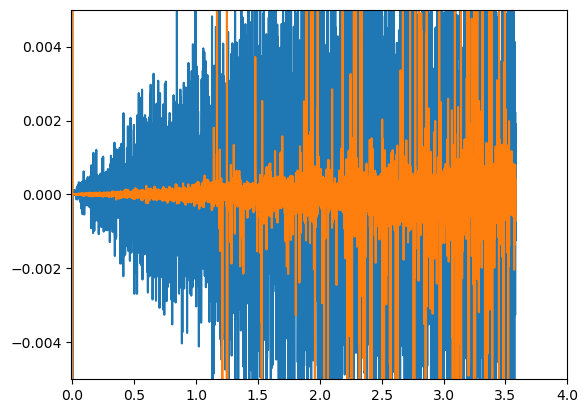

In [46]:
## what it looked like previous to deleting runs

allNaI_raw = np.sum(sum_ch_raw[3:5], axis = 0)
%matplotlib inline
print(len(allNaI_raw))
plt.plot(xs, sum_ch_raw[1]/np.sum(all_sequences))
plt.plot(xs, allNaI_raw/np.sum(all_sequences)/24)
plt.ylim(-0.005, 0.005)
plt.xlim(-0.01, 4.0)

-0.07288897630071575


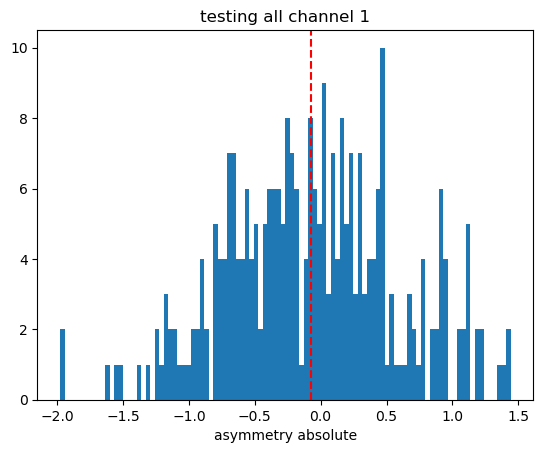

In [37]:
## idk what this is...

%matplotlib inline
ch = 1
plt.hist(all_amp[ch], bins = 100)
chmean = np.mean(all_amp[ch])
print(chmean)
plt.axvline(x=chmean,ls='--', c ='r')

plt.xlabel('asymmetry absolute')
plt.ylabel('')
plt.title(f'testing all channel {ch}')
# plt.legend()
plt.show()

In [31]:
# ## previously used for checking vstack

# %matplotlib inline
# # all_raw = np.vstack((all_raw_D,all_raw_U))
# # all_amp = np.vstack((all_amp_D,all_amp_U))
# # all_amp_norm = all_amp/all_sequences

# # plt.plot(xs, all_raw_D[-1][20])
# # plt.plot(xs, all_raw[11][20])
# plt.plot(xs, all_raw_U[-1][20])
# plt.plot(xs, all_raw[-1][20])
# plt.ylim(-100, 100)
# plt.xlim(-0.01, 3)
# # print(len(all_raw_D[0]))
# for i in range(0,12):
#     if all_raw_U[i][20][50] == all_raw[i+12][20][50]:
#         print('yay')
#     if all_raw_D[i][20][50] == all_raw[i][20][50]:
#         print('yay 2')
#     else: 
#         print('boo')
# # testrans = np.asarray(all_raw_D.transpose(1,0,2))
# # testranssum = np.sum(testrans[ch,:], axis = 0)
# # plt.plot(xs, testranssum)

In [ ]:
## testing for outlier runs
# ch = 0
# for ch in range(0, 1):
problem_files = [[],[]]
outlier_thresh = 50
start_b = 2300

for ch in range(0, len(all_raw_U)):
# for ch in range(0, 2):
    # plt.figure()
    for i in range(0, len(all_raw_U[0])):
        if np.max(np.abs(all_raw_U[ch,i,start_b:])) >= outlier_thresh:
            problem_files[0].append(ch)
            problem_files[1].append(i) 
            # print(ch, i, np.max(all_raw_U[ch,i,2200:]))
            plt.plot(all_raw_U[ch,i])

plt.axvline(start_b, ls = '--')
plt.axhline(outlier_thresh, ls = '--')
plt.show()
print(problem_files)
print(np.unique(np.sort(problem_files[1])))

print(all_raw_U.shape)
test_del = all_raw_U.copy()
test_prob_f = np.unique(np.sort(problem_files[1]))
print(test_prob_f)
print(len(test_prob_f))
test_new = np.delete(test_del, test_prob_f, axis=1)

print(test_new.shape)

%matplotlib qt
p = 0
plt.plot(all_raw_U[0][p], label='og')
plt.plot(all_raw_U[0][p+1], label = 'og+1', ls ='-.')
plt.plot(test_new[0][p], label = 'test del p ', ls ='--')
plt.plot(test_new[0][p+1], label = 'test del p+1', ls ='--')

plt.ylim(-100, 100)
plt.legend()

# print(all_raw_U[0][0][2200:2205])
# print(all_raw_U[0,0:p+6,2200:2205])
# # print(all_raw_U[0][p-1][2200:2205])
# # print(all_raw_U[0][p][2200:2205])
# # print(all_raw_U[0][p+1][2200:2205])
# # print(all_raw_U[0][p+2][2200:2205])
# # print(all_raw_U[0][p+3][2200:2205])
# # print(all_raw_U[0][p+4][2200:2205])
# print()
# # print(test_new[0][p-2][2200:2205])
# # print(test_new[0][p-1][2200:2205])
# # print(test_new[0][p][2200:2205])
# # print(test_new[0][p+1][2200:2205])
# # print(test_new[0][p+2][2200:2205])
# # print(test_new[0][p+3][2200:2205])
# # print(test_new[0][p+4][2200:2205])
# print(test_new[0,0:p+4,2200:2205])

sum_ch_raw = []
sum_ch_amp = []
p1 = 300
p2 = 400
for ch in range(0, len(all_raw)):
    chraw = np.sum(all_raw[ch,p1:p2], axis = 0)
    sum_ch_raw.append(chraw)
for ch in range(0, len(all_amp)):
    champ = np.sum(all_amp[ch,p1:p2], axis = 0)
    sum_ch_amp.append(champ)

sum_ch_raw = np.array(sum_ch_raw)
    
sum_ch_amp = sum_ch_amp/np.sum(all_sequences) ## normalize sum of amplitudes!
    
print(len(sum_ch_raw), len(sum_ch_amp))
print(len(sum_ch_raw[0]))
allNaI_raw = np.sum(sum_ch_raw[0:23], axis = 0)

%matplotlib qt
print(len(allNaI_raw))
plt.plot(xs, sum_ch_raw[2]/np.sum(all_sequences))
# plt.plot(xs, allNaI_raw/np.sum(all_sequences)/24)
plt.ylim(-0.02, 0.02)
plt.xlim(-0.01, 3.5)
# print(len(all_raw_D[0]))
print(sum_ch_amp)

### paper plotting

# only run once!

24 24
8992
8992


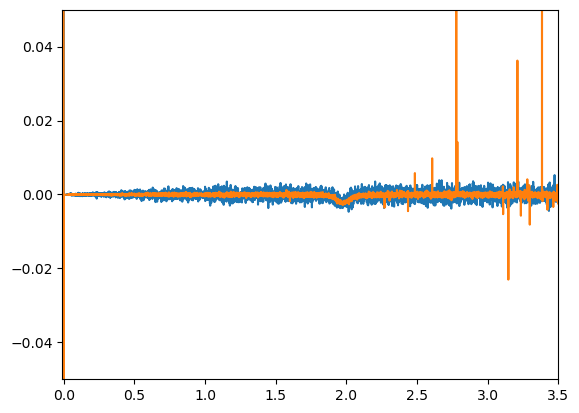

(24, 954, 8992)
deleted a run 109. New shape:  (24, 953, 8992)
New added D/U pulses shape:  (13, 953, 8992) (13, 953, 8992)
24 24
8992
8992


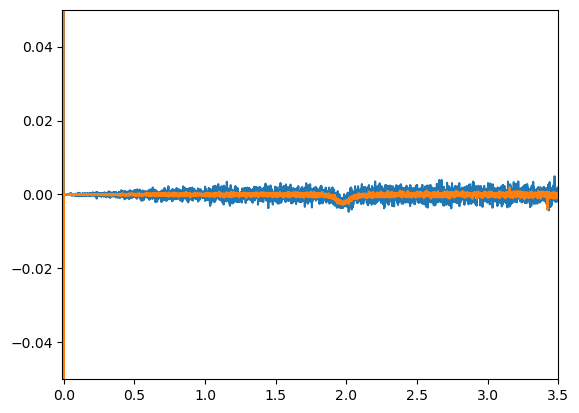

In [32]:
## Testing deleting a specific troublesome run

sum_ch_raw = []
sum_ch_amp = []
for ch in range(0, len(all_raw)):
    chraw = np.sum(all_raw[ch,:], axis = 0)
    champ = np.sum(all_amp[ch,:], axis = 0)
    sum_ch_raw.append(chraw)
    sum_ch_amp.append(champ)

    
sum_ch_amp = sum_ch_amp/np.sum(all_sequences) ## normalize sum of amplitudes!
    
print(len(sum_ch_raw), len(sum_ch_amp))
print(len(sum_ch_raw[0]))

allNaI_raw = np.sum(sum_ch_raw[:], axis = 0)
print(len(allNaI_raw))

plt.figure()
%matplotlib inline
plt.plot(xs, sum_ch_raw[1]/np.sum(all_sequences))
plt.plot(xs, allNaI_raw/np.sum(all_sequences)/24)
plt.ylim(-0.05, 0.05)
plt.xlim(-0.01, 3.5)
plt.show()
# print(len(all_raw_D[0]))
# print(sum_ch_amp)

#############################################################################
if folders_start == 'runs11727-12033':
    tb = 109
    print(all_raw.shape)
    all_raw = np.delete(all_raw, tb,1)
    all_D = np.delete(all_D, tb,1)
    all_U = np.delete(all_U, tb,1)
    print(f'deleted a run {tb}. New shape: ', all_raw.shape)
    print(f'New added D/U pulses shape: ', all_D.shape, all_U.shape)
else:
    print('No runs deleted. Shape: ', all_raw.shape)
    print(f'D/U pulses shape: ', all_D.shape, all_U.shape)
    
#############################################################################
sum_ch_raw = []
sum_ch_amp = []
for ch in range(0, len(all_raw)):
    chraw = np.sum(all_raw[ch,:], axis = 0)
    champ = np.sum(all_amp[ch,:], axis = 0)
    sum_ch_raw.append(chraw)
    sum_ch_amp.append(champ)

    
sum_ch_amp = sum_ch_amp/np.sum(all_sequences) ## normalize sum of amplitudes!
    
print(len(sum_ch_raw), len(sum_ch_amp))
print(len(sum_ch_raw[0]))

allNaI_raw = np.sum(sum_ch_raw[:], axis = 0)
print(len(allNaI_raw))

plt.figure()
plt.plot(xs, sum_ch_raw[1]/np.sum(all_sequences))
plt.plot(xs, allNaI_raw/np.sum(all_sequences)/24)
plt.ylim(-0.05, 0.05)
plt.xlim(-0.01, 3.5)
plt.show()
# print(len(all_raw_D[0]))


### plotting for paper

In [59]:
from functools import reduce
def factors(n):
    return set(reduce(list.__add__,([i, n//i] for i in range(1, int(n**0.5) + 1) if n % i == 0)))

def rebin(ys, xs, rebinfactor):
    outys = ys.reshape(-1, rebinfactor).mean(axis=1)
    outxs = xs.reshape(-1, rebinfactor).mean(axis=1)
    return outys, outxs

# rebinf = rebinfactors[6]
# print(f'using factor {rebinf}')
# y2_rebin, x_rebin = rebin(y2, x, rebinf)


In [60]:
pulseadd_D = np.sum(all_D[:], axis = 1)

# Sample data
# r = 550
r1 = 2001
r2 = 8501

ch = 1
x = xs[r1:r2]
y1 = pulseadd_D[ch][r1:r2]
# y2 = allNaI_raw[r1:r2]/np.sum(all_sequences)/24*-1 ## flip the sign for plotting
y2 = sum_ch_raw[ch][r1:r2]/np.sum(all_sequences)*-1 ## flip the sign for plotting

rebinfactors = np.sort(np.array(list(factors(len(y2)))))
print(f'possible factors are ', rebinfactors)

rebinf = rebinfactors[5]
print(f'using factor {rebinf}')

y2_rebin, x_rebin = rebin(y2, x, rebinf)

possible factors are  [   1    2    4    5   10   13   20   25   26   50   52   65  100  125
  130  250  260  325  500  650 1300 1625 3250 6500]
using factor 13


In [61]:
%matplotlib qt
# Create the main plot
fig, ax1 = plt.subplots()
lw = 1.2
plt.rcParams["font.family"] = "sans-serif"

# Plot the first dataset
ax1.plot(x, y1, color='blue', label=f'La spectra {channels_all[ch]}', linewidth = lw)
ax1.set_ylabel(r'Counts [arb.]', fontsize='large', color = 'blue')
ax1.set_xlabel('ToF [ms]', fontsize='large')
ax1.tick_params(axis='x', labelsize = 'large')
ax1.tick_params(axis='y', labelsize = 'large', labelcolor = 'blue')
# plt.ylim(0,20)

# Create a twin axes sharing the x-axis
ax2 = ax1.twinx()

# Plot the second dataset

# ax2.plot(x, ydata, color ='blue',alpha = 0.6)
ax2.plot(x_rebin, y2_rebin, ls = '-', color='red', alpha = 1.0, label='"Raw" Asymmetry', linewidth = lw)
# ax2.set_xlabel('Energy [eV]',fontsize = 'large')
ax2.set_ylabel('Asymmetry [absolute]', fontsize='large', color='red')
ax2.tick_params(axis='y', labelsize = 'large', labelcolor = 'red')


# Set y-axis limits
ax1.set_ylim(-0.01e9, 0.5e9)
ax2.set_ylim(-0.004, 0.006)

# Add legends
# fig.legend(loc="upper right", bbox_to_anchor=(0.1, 0.95))


# Display the plot

plt.title(r'La Spectra and Asymmetry', fontsize = 'xx-large')

# plt.xticks(np.arange(-1.0,4.0, 0.5),fontsize = 'large')
ax1.grid(True, which='both',axis = 'both', alpha = 0.75, ls = ':')
ax1.minorticks_on()
# plt.xticks(fontsize = 'xx-large')
# plt.yticks(fontsize = 'x-small')
fig.legend(loc="upper right", bbox_to_anchor=(0.86, 0.88))

# plt.ylabel('NMR Signal Amplitude [mV]',fontsize = 'x-large')
# plt.xlabel('Energy [eV]',fontsize = 'x-large')

# plt.legend(fontsize = 'medium')
plt.show()

In [40]:
fig, ax1 = plt.subplots()
lw = 1.2

# Plot the first dataset
ax1.plot(x, y1, color='blue', label=f'La spectra {channels_all[ch]}', linewidth = lw)
ax1.set_ylabel(r'Counts [arb.]', fontsize='large', color = 'blue')
ax1.set_xlabel('ToF [ms]', fontsize='large')
ax1.tick_params(axis='x', labelsize = 'large')
ax1.tick_params(axis='y', labelsize = 'large', labelcolor = 'blue')

# Create a twin axes sharing the x-axis
ax2 = ax1.twinx()

# Plot the second dataset

# ax2.plot(x, ydata, color ='blue',alpha = 0.6)
ax2.plot(x_rebin, y2_rebin, ls = '-', color='red', alpha = 1.0, label='asymmetry', linewidth = lw)
# ax2.set_xlabel('Energy [eV]',fontsize = 'large')
ax2.set_ylabel('Asymmetry [absolute]', fontsize='large', color='red')
ax2.tick_params(axis='y', labelsize = 'large', labelcolor = 'red')


# Set y-axis limits
ax1.set_ylim(-0.01e9, 0.5e9)
ax2.set_ylim(-0.004, 0.006)

plt.title(r'La spectrum and asymmetry new temp ', fontsize = 'xx-large')

ax1.grid(True, which='both',axis = 'both', alpha = 0.75, ls = ':')
ax1.minorticks_on()
# plt.xticks(fontsize = 'xx-large')
# plt.yticks(fontsize = 'x-small')
fig.legend(loc="upper right", bbox_to_anchor=(0.90, 0.88))

# plt.legend(fontsize = 'medium')
plt.show()

### end paper plotting

In [192]:
ch = 10
print(len(np.sum(all_raw_D[:,ch], axis = 0)))
testsum = np.sum(all_raw_D[:,ch], axis = 0)
print(testsum)
%matplotlib qt
print(xs)
plt.plot(xs, testsum)
plt.ylim(-100, 100)
plt.xlim(-0.01, 3)
print(len(all_raw_D[0]))

testrans = np.asarray(all_raw_D.transpose(1,0,2))
testranssum = np.sum(testrans[ch,:], axis = 0)
plt.plot(xs, testranssum)
print(testranssum)

8992
[3.77280648e+03 8.52370423e+01 3.22309869e+04 ... 8.21254420e+00
 7.29478682e+00 7.68468218e+00]
[-1.021952 -1.02144  -1.020928 ...  3.580416  3.580928  3.58144 ]
12
[3.77280648e+03 8.52370423e+01 3.22309869e+04 ... 8.21254420e+00
 7.29478682e+00 7.68468218e+00]


In [185]:
print(all_raw_D.shape)
print(all_raw_D[14][5][20:30])
print(all_raw_D[31][6][20:30])

testrans = np.asarray(all_raw_D.transpose(1,0,2))
print(testrans.shape)
print(testrans[5][14][20:30])
print(testrans[6][31][20:30])

(636, 12, 8992)
[ 42.10536834   0.49624384  10.69471701 -21.74036183  32.21412419
 -15.25067682  15.21694059  11.04733538 -60.47922312  -0.58353548]
[  5.43475669  19.3607907   18.19386519  36.15928555  13.78356287
  13.87217111  34.28298049  18.01152043 -56.81306022  20.88652147]
(12, 636, 8992)
[ 42.10536834   0.49624384  10.69471701 -21.74036183  32.21412419
 -15.25067682  15.21694059  11.04733538 -60.47922312  -0.58353548]
[  5.43475669  19.3607907   18.19386519  36.15928555  13.78356287
  13.87217111  34.28298049  18.01152043 -56.81306022  20.88652147]


In [173]:
asyms_raw_summed = []
for ch in range(0, len(all_raw_D[0])):
    chsum = np.sum(all_raw_D[:,ch], axis = 0) 
    asyms_raw_summed.append(chsum)
    
print(len(asyms_raw_summed))
plt.plot(xs, asyms_raw_summed[2])

12


In [175]:
asyms_raw_allNaI = np.sum(asyms_raw_summed[:], axis = 0) 
print(len(asyms_raw_allNaI))
plt.plot(asyms_raw_allNaI)

8992


In [24]:
## need to make this into function and faster

run_asyms_D = np.zeros((numruns,len(arr_sizer),len(arr_sizer[0])), dtype=float) ## num pulses, num channels, num points (one dataset per pulse per channel)
run_asyms_U = np.zeros((numruns,len(arr_sizer),len(arr_sizer[0])), dtype=float) ## num pulses, num channels, num points (one dataset per pulse per channel)
run_asyms_U_noLi = np.zeros((numruns,len(arr_sizer)-1,len(arr_sizer[0])), dtype=float) ## take out 6Li in upstream (can this be done above?)
run_asyms_All = np.zeros((numruns,25,len(arr_sizer[0])), dtype=float) ## num pulses, num channels, num points (one dataset per pulse per channel)


for i in range(numruns):
    run_asyms_D[i] = np.load(root+processedfolder+folders_start+asymDendname+runslist_D[i])
    run_asyms_U[i] = np.load(root+processedfolder+folders_start+asymUendname+runslist_U[i])
    run_asyms_U_noLi[i] = run_asyms_U[i,:-1].copy()
    run_asyms_All[i] = np.vstack((run_asyms_U_noLi[i], run_asyms_D[i]))
    
print(len(run_asyms_U_noLi))
print(len(run_asyms_U_noLi[0]))
print(len(run_asyms_U_noLi[0][0]))
print(len(run_asyms_D))
print(len(run_asyms_D[0]))
print(len(run_asyms_D[0][0]))

print(len(run_asyms_All))
print(len(run_asyms_All[0]))
print(len(run_asyms_All[0][0]))

ch_asyms_All = run_asyms_All.transpose(1, 0, 2) ## switches first array to channels and second array to pulses

print(len(ch_asyms_All))
print(len(ch_asyms_All[0]))
print(len(ch_asyms_All[0][0]))

print((ch_asyms_All[0][0][0:5]))
print((run_asyms_U_noLi[0][0][0:5]))
print((run_asyms_D[0][0][0:5]))
print()
print((ch_asyms_All[-1][0][0:5]))
print((run_asyms_D[0][-1][0:5]))
print()
print((ch_asyms_All[12][0][0:5]))
print((run_asyms_D[0][0][0:5]))
print((ch_asyms_All[11][0][0:5]))
print((run_asyms_U_noLi[0][-1][0:5]))
print()
print((ch_asyms_All[-1][0][0:5]))
print((ch_asyms_All[-1][-1][0:5]))

# print((run_asyms_U_noLi[0][0][0:5]))
# print((run_asyms_D[0][0][0:5]))

# print((run_asyms_All[0][0][0:5]))
# print((run_asyms_All[0][-1][0:5]))
# print((run_asyms_D[0][-1][0:5]))


NameError: name 'numruns' is not defined

In [10]:
# print((new_run_asyms_All[0][1][0:5]))
# print((new_run_asyms_All[0][0][0:5]))

# print((new_run_asyms_All[2][-1][0:5]))
# print((new_run_asyms_All[2][-2][0:5]))

In [11]:
print(len(run_asyms_D))
print(len(run_asyms_D[0]))
print(len(run_asyms_D[0][0]))

330
13
9000


In [12]:

xs_cut = np.load(root+processedfolder+'xs_cut.npy')
xs_uncut = np.load(root+processedfolder+'xs_uncut.npy')
xs_cut = xs_cut/1000000
xs_uncut = xs_uncut/1000000  ## convert to ms...

print(len(xs_cut))
print(len(xs_cut[0]))

print(len(xs_uncut))
print(len(xs_uncut[0]))

13
8992
13
9000


In [13]:
All_Li6_asyms = np.zeros((len(arr_sizer[0])), dtype=float) ## num points
for r in range(len(ch_asyms_All[0])):
    All_Li6_asyms = All_Li6_asyms + ch_asyms_All[-1][r]
All_Li6_asyms = All_Li6_asyms/numruns
    
NaI_asyms = np.zeros((len(ch_asyms_All)-1, len(arr_sizer[0])), dtype=float) ## num points
for i in range(24): ## 0-11, (24 is 6Li)
    for r in range(len(ch_asyms_All[0])):
        NaI_asyms[i] = NaI_asyms[i] + ch_asyms_All[i][r]
NaI_asyms = NaI_asyms/numruns
        
All_NaI_asyms = np.zeros((len(arr_sizer[0])), dtype=float) ## num points
for i in range(24): ## 0-23, not 0-24 (24 is 6Li)
    for r in range(len(ch_asyms_All[0])):
        All_NaI_asyms = All_NaI_asyms + ch_asyms_All[i][r]
All_NaI_asyms = All_NaI_asyms/numruns

upstrm = np.zeros((len(arr_sizer[0])), dtype=float) ## num points
for i in range(12): ## 0-23, not 0-24 (24 is 6Li)
    print(i)
    for r in range(len(ch_asyms_All[0])):
        upstrm = upstrm + ch_asyms_All[i][r]
upstrm = upstrm/numruns
print()
dnstrm = np.zeros((len(arr_sizer[0])), dtype=float) ## num points
for i in range(12,24): ## 0-23, not 0-24 (24 is 6Li)
    print(i)
    for r in range(len(ch_asyms_All[0])):
        dnstrm = dnstrm + ch_asyms_All[i][r]
dnstrm = dnstrm/numruns
# Upstrm_NaI_asyms = np.zeros((len(arr_sizer[0])), dtype=float) ## num points
# for i in range(12): ## 0-11, (24 is 6Li)
#     for r in range(len(ch_asyms_All[0])):
#         Upstrm_NaI_asyms = Upstrm_NaI_asyms + ch_asyms_All[i][r]

# Dnstrm_NaI_asyms = np.zeros((len(arr_sizer[0])), dtype=float) ## num points

# for i in range(12,24): ## 12-23, not 12-24 (24 is 6Li)
# #     print( i )
#     Dnstrm_NaI_asyms = Dnstrm_NaI_asyms + ch_asyms_All[i]

print(len(All_NaI_asyms))
print(len(All_Li6_asyms))
print()

print(len(NaI_asyms))
print(len(NaI_asyms[0]))
# print(len(Upstrm_NaI_asyms))
# print(len(Dnstrm_NaI_asyms))


0
1
2
3
4
5
6
7
8
9
10
11

12
13
14
15
16
17
18
19
20
21
22
23
9000
9000

24
9000


In [14]:
print(numruns)

330


In [15]:
print(len(run_asyms_U_noLi))
print(run_asyms_U_noLi[20,11,2000:2010])
print(run_asyms_U_noLi[20][11][2000:2010])

print(len(run_asyms_U_noLi[0:330,11,2000:2010]))
print(len(run_asyms_U_noLi[0:330][11][2000:2010]))

# print((run_asyms_U_noLi[0][5][4000:4010]*330))
print(np.average(run_asyms_U_noLi[0:380,11,7900]*330))
print(NaI_asyms[11][7900])

330
[-0.00019739 -0.00019493 -0.00019349 -0.00019422 -0.00019638 -0.00019512
 -0.00019456 -0.00019479 -0.00019415 -0.00019385]
[-0.00019739 -0.00019493 -0.00019349 -0.00019422 -0.00019638 -0.00019512
 -0.00019456 -0.00019479 -0.00019415 -0.00019385]
330
0
0.13468340116256292
0.0004081315186744347


In [16]:
m = 8
# a = All_Li6_asyms
a = All_NaI_asyms
b = a.reshape(-1, m).mean(axis=1)
c = xs_cut[0]
d = c.reshape(-1, m).mean(axis=1)
print(len(a))
print(len(b))
print(len(d))

def rebin(ys, xs, rebinfactor):
    outys = ys.reshape(-1, rebinfactor).mean(axis=1)
    outxs = xs.reshape(-1, rebinfactor).mean(axis=1)
    return outys, outxs

rebinf = 8
All_NaI_asyms_rebin8, xs_cut_rebin8 = rebin(All_NaI_asyms, xs_cut[0], rebinf)
All_Li6_asyms_rebin8, xs_cut_rebin8 = rebin(All_Li6_asyms, xs_cut[0], rebinf)

print(len(All_NaI_asyms_rebin8))
print(len(xs_cut_rebin8))

9000
1125
1124
1125
1124


In [17]:
print(numruns)

330


In [21]:
# legend = []
%matplotlib qt

# plt.plot(xs_uncut[0], NaI_asyms[1] , label='NaI D1')
# plt.plot(xs_cut[0], NaI_asyms[1] , label='NaI D1')
# plt.plot(xs_cut[0], All_NaI_asyms/(24), label='All NaI')
# plt.plot(xs_cut[0], (All_NaI_asyms/(24)), label='All NaI, no rebinning: ')
# plt.plot(xs_uncut[0], (All_NaI_asyms/(24)), label='All NaI, no rebinning. No t0 alignment')
# plt.plot(xs_cut[0], (upstrm/(12)), label='upstrm, no rebinning: ')
# plt.plot(xs_cut[0], (dnstrm/(12)), label='dnstrm, no rebinning: ')

# plt.plot(xs_cut[0], (All_Li6_asyms), label='Li6, no rebinning: ')
# plt.plot(xs_cut_rebin8, (All_NaI_asyms_rebin8/(24)), label='All NaI, rebinning: ' + str(rebinf))
# plt.plot(xs_cut_rebin8, (All_Li6_asyms_rebin8), label='Li6, rebinning: ' + str(rebinf))

# plt.plot(xs_uncut[0], NaI_asyms[7] , label='NaI D1')
plt.plot(d, b[:-1]/24, label='All NaI')

# plt.plot(xs_uncut[0], All_Li6_asyms , label='6Li')
# plt.plot(xs_cut, All_Li6_asyms/4275 , label='6Li')
# plt.plot(d, b, label='6Li')

    
plt.title(f'asym, {numruns} runs, (' + str(numruns*4/60) + ' hours)') 
plt.xlabel("time from trigger (ms)")
plt.ylabel('absolute')

plt.ylim(-0.5,0.5)
# plt.xlim(xs_cut[1800],xs_cut[-1])
# plt.xlim(xs_uncut[0][1800],xs_uncut[0][-1])

# plt.axvline(xs[0][baseL], ls = '--')
# plt.axvline(xs[0][baseR], ls = '--')
# plt.axvline(xs_cut[1][7800], ls = '--', c ='g')
plt.axvline(xs_cut[1][7500], ls = '--', c ='r')
plt.axvline(xs_cut[1][7200], ls = '--', c ='r')

#plt.axvline(xs[1][intgrR], ls = '--', c ='g')
#plt.axvline(xs[2][HeintgrL], ls = '--', c ='r')
#plt.axvline(xs[2][HeintgrR], ls = '--', c ='r')

plt.legend()
plt.show()

In [ ]:
print(root+processedfolder+folders_start+'/asym_D/'+runslist_D[1])

In [ ]:
xs_uncut = np.load(root+processedfolder+'xs_uncut.npy')
print(len(xs_uncut[0]))

In [16]:
testload0 = np.load(root+processedfolder+folders_start+'/asym_D/'+runslist_D[0])
testload1 = np.load(root+processedfolder+folders_start+'/asym_D/'+runslist_D[1])
testload2 = np.load(root+processedfolder+folders_start+'/asym_D/'+runslist_D[2])
testload3 = np.load(root+processedfolder+folders_start+'/asym_D/'+runslist_D[3])
testload4 = np.load(root+processedfolder+folders_start+'/asym_D/'+runslist_D[4])
testload5 = np.load(root+processedfolder+folders_start+'/asym_D/'+runslist_D[5])
testload6 = np.load(root+processedfolder+folders_start+'/asym_D/'+runslist_D[6])
testload7 = np.load(root+processedfolder+folders_start+'/asym_D/'+runslist_D[7])
testload8 = np.load(root+processedfolder+folders_start+'/asym_D/'+runslist_D[8])
testload9 = np.load(root+processedfolder+folders_start+'/asym_D/'+runslist_D[9])
testload10 = np.load(root+processedfolder+folders_start+'/asym_D/'+runslist_D[10])
testload11 = np.load(root+processedfolder+folders_start+'/asym_D/'+runslist_D[11])
testload12 = np.load(root+processedfolder+folders_start+'/asym_D/'+runslist_D[12])
testload13 = np.load(root+processedfolder+folders_start+'/asym_D/'+runslist_D[13])
testload14 = np.load(root+processedfolder+folders_start+'/asym_D/'+runslist_D[14])
testload15 = np.load(root+processedfolder+folders_start+'/asym_D/'+runslist_D[15])
testloads = [testload1, testload2, testload3, testload4, testload5, testload6, testload7, testload8, testload9, testload10, testload11, testload12, testload13, testload14, testload15, testload0]

print(len(testload0))
print(len(testload0[0]))


13
8992


In [17]:
print(type(testload12))
print(len(testload12))
print(len(testload12[1]))
print(testload12[1][2100:2110])

print(type(testload1))
print(len(testload1))
print(len(testload1[1]))
print(testload1[1][2100:2110])

<class 'numpy.ndarray'>
13
8992
[ 0.00545513 -0.00232839  0.00913183  0.00257728 -0.00176993  0.00101849
  0.00163765  0.00434007  0.00353119  0.00101663]
<class 'numpy.ndarray'>
13
8992
[ 0.00149679 -0.00161068 -0.00074242 -0.0005354  -0.00117681 -0.00113059
  0.0050438  -0.00223947 -0.00453362 -0.00859197]


In [18]:
testa = np.array([1,4,10])
testb = np.array([6,2,-1])
tests = [testa, testb]

print(np.sum(tests, axis =0))
print(testa+testb)

[7 6 9]
[7 6 9]


In [19]:
alltests = np.zeros((len(testload1),len(testload1[0])), dtype=np.float64)
for i in range(len(testloads)):
    for ch in range(len(testloads[0])):
        alltests = np.add(alltests,testloads[i][ch])



In [20]:
# alltests = np.sum(testloads, axis =0)
print(len(alltests))
print(len(alltests[0]))
print(alltests[-1][2100:2110])
print(testloads[-1][2][2100:2110])

13
8992
[ 0.06580914 -0.00674936  0.01945315 -0.04193713  0.00197393  0.0245911
  0.07918334  0.07143564  0.00753719  0.00066482]
[ 0.00239088  0.00161905 -0.00045938 -0.00167427  0.00082221  0.00120667
 -0.00058788 -0.00259709  0.00513048  0.00540297]


In [23]:
# legend = []
%matplotlib qt

# plt.plot(xs_uncut[0], alltests[0] , label='alltests')
# plt.plot(xs_uncut[0], testload1[1] , label='testload1')
# plt.plot(xs_cut[0], NaI_asyms[0] , label='NaI D1')
# plt.plot(xs_cut, NaI_asyms[5] , label='NaI D1')
# plt.plot(xs_cut, NaI_asyms[19] , label='NaI D1')
# plt.plot(xs_cut, NaI_asyms[21] , label='NaI D1')

# plt.plot(xs_cut, ch_asyms[2] , label='NaI D1')
# plt.plot(xs_cut, All_NaI_asyms/24, label='All NaI')
# plt.plot(d, b/24, label='All NaI')

# plt.plot(xs_cut, All_Li6_asyms , label='6Li')
# plt.plot(xs_cut, All_Li6_asyms/4275 , label='6Li')
# plt.plot(d, b, label='6Li')

    
plt.title('asym') 
plt.xlabel("time from trigger (ns)")
plt.ylabel("ADC")

plt.ylim(-3,3)
# plt.xlim(xs_cut[1800],xs_cut[-1])
plt.xlim(xs_uncut[0][1800],xs_uncut[0][-1])

# plt.axvline(xs[0][baseL], ls = '--')
# plt.axvline(xs[0][baseR], ls = '--')
#plt.axvline(xs[1][intgrL], ls = '--', c ='g')
#plt.axvline(xs[1][intgrR], ls = '--', c ='g')
#plt.axvline(xs[2][HeintgrL], ls = '--', c ='r')
#plt.axvline(xs[2][HeintgrR], ls = '--', c ='r')

plt.legend()
plt.show()

In [18]:
a = np.array([[2,6,8,9,30], [2,6,8,9,30]*4])
b = np.array([[1,3,2,3,10], [2,6,8,9,30]*2])
c = np.divide(a,b)
print(c)

C:\Users\gabeo\AppData\Local\Temp\ipykernel_85532\1335267064.py:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  a = np.array([[2,6,8,9,30], [2,6,8,9,30]*4])
C:\Users\gabeo\AppData\Local\Temp\ipykernel_85532\1335267064.py:2: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  b = np.array([[1,3,2,3,10], [2,6,8,9,30]*2])


TypeError: unsupported operand type(s) for /: 'list' and 'list'

In [24]:
import os
import numpy as np
os.chdir('F:/LANL/processed_data/')

searchfolder = 'F:/LANL/processed_data/'
search_arr = sorted(os.listdir(os.getcwd()))
print(search_arr)
print(search_arr[0])
folder_start = 'runs'+'12034-12363'
folder_end = 'runs'+'12364-12684'
# folder_end = 'testother2'
print(folder_start)
start_i = search_arr.index(folder_start)
end_i = search_arr.index(folder_end)
print(start_i)
print(end_i)

firstfile = sorted(os.listdir(searchfolder+folder_start+'/asym_D'))[0]
arr_sizer = np.load(searchfolder+folder_start+'/asym_D/'+firstfile)
print(arr_sizer)
print(len(search_arr[start_i:end_i+1]))
print(len(arr_sizer))
print(len(arr_sizer[0]))
# print(len(arr_size[0][0]))
numruns = len(sorted(os.listdir(searchfolder+folder_start+'/asym_D')))
# print(numruns)
# run_asyms = np.zeros((numruns,len(arr_sizer),len(arr_sizer[0])), dtype=float)
# print(len(run_asyms))
# print(len(run_asyms[0]))
# print(len(run_asyms[0][0]))

folder_arr = []

# dir = folder_start + folder_start
for dir in search_arr[start_i:end_i+1]:
    run_asyms = np.zeros((numruns,len(arr_sizer),len(arr_sizer[0])), dtype=float)
    # folder_arr.append(run_asyms)
    print(dir)
    for file in ((sorted(os.listdir(searchfolder+dir+'/asym_D')))):
        # print(file)
        if file[-5] == 'U': ## Up and Down stream. Case sensitive!
            print(file)
        elif file[-5] == 'D':
            ## add to downstream sums
            print(file)
            # print(os.listdir(searchfolder+dir+'/asym')[file]+'hihihi')
        # if file.endswith == 'D.npy':
        #     print(os.listdir(searchfolder+dir+'/asym')[file]+'hihihi')
    #     run_asyms[file] = np.load(searchfolder+dir+'/asym/'+file)
    # folder_arr.append(run_asyms)

['La_sample', '_temp_xs.npy', 'runs11139-11412', 'runs11413-11726', 'runs11727-12033', 'runs12034-12363', 'runs12364-12684', 'runs13564-13604', 'runs13605-13735', 'runs13736-13851', 'runs88888-99999', 'testother', 'testother2', 'xs_cut.npy', 'xs_uncut.npy']
La_sample
runs12034-12363
5
6
[[-3.69633597e-01 -2.63165523e+00 -3.56222096e-01 ...  7.36716205e-02
  -2.55044314e-02 -1.71281466e-02]
 [ 6.17067505e-03 -1.30841489e+00  6.78591744e-01 ... -1.34713175e-04
  -5.34848008e-02 -7.30152590e-02]
 [ 2.31972124e-02 -1.91469631e+00  5.00007395e-02 ... -2.82448048e-02
  -3.13920185e-02 -3.43898985e-02]
 ...
 [ 8.50719814e-01  1.38581159e+00 -2.28252735e+00 ... -1.04070546e-02
  -7.99308281e-02  2.57297331e-02]
 [-8.17663618e-03 -1.30692453e+00  3.52806129e+00 ...  2.36817996e-02
  -3.65283320e-02 -3.03282009e-02]
 [ 4.34295148e-03  6.05849456e-02 -5.80115256e-02 ... -4.32947513e-03
  -8.30378287e-03  1.41922170e-04]]
2
13
8992
runs12034-12363
12034_asym_D.npy
12035_asym_D.npy
12036_asym_D.npy

In [3]:

# In[13]:
import sys
import numpy as np
import matplotlib.pyplot as plt
#import uproot
import pandas as pd
import statistics as st
import os
from numba import njit
import time
from numba.core.errors import NumbaDeprecationWarning, NumbaPendingDeprecationWarning
import warnings
from loguru import logger

warnings.simplefilter('ignore', category=NumbaDeprecationWarning)
warnings.simplefilter('ignore', category=NumbaPendingDeprecationWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

# for arg in sys.argv:
#     run_num=str(arg).zfill(5)
#     # print(run_num)

# chan_enab = int(sys.argv[-1])
# run_start=str(sys.argv[1]).zfill(5)
# run_end=str(sys.argv[2]).zfill(5)
# run_num=str(sys.argv[3]).zfill(5)
run_num = "11164" 

# print(os.getcwd())
os.chdir('F:/LANL/')
datadir = 'D:\LANSCE_FP12_2023\data/'
folder = 'runs11139-11412/'
SFNormFile = 'SF_Norm_files/'+folder+run_num
# datadir = 'D:/LANSCE_FP12_2023/data/' ## add directory of hard drive
# uniquefolder = "runs" + str(run_start) + "-" + str(run_end) +"/"
# SFNormFile = 'SF_Norm_files/'+uniquefolder+run_num

statefileloc = 'F:\LANL\SF_Norm_files\TR_R_expected_avgs_stds_afterclip.csv'
# processedpulsefolder = '/processed_data/'+uniquefolder+'pulses_added/'
# processedasymfolder = '/processed_data/'+uniquefolder+'asym/'
# AddedPulseSavename = processedpulsefolder+run_num+'_pulsesadded_d'
# AsymSavename = processedasymfolder+run_num+'_asym_d'
# logger.add("F:/LANL/processed_data/" + uniquefolder + '0_ErrorLog_'+run_start+'_'+run_end+'.txt', delay = False)

# print('processing data: ' + uniquefolder + '/run' + run_num)

# AddedPulseSavename = processedpulsefolder+uniquefolder+run_num+'_pulsesadded_d'
# AsymSavename = processedasymfolder+uniquefolder+run_num+'_asym_d'
# print(os.getcwd()+processedpulsefolder)
# if not os.path.exists(os.getcwd()+processedpulsefolder) or not os.path.exists(os.getcwd()+processedasymfolder):
#     # Create the directory
#     os.makedirs(os.getcwd()+processedpulsefolder)
#     os.makedirs(os.getcwd()+processedasymfolder)
#     print("Directory created successfully")
# else:
#     pass

# print(os.getcwd() + folder)

# get_ipython().run_line_magic('matplotlib', 'qt')

start = time.time()
fullstart = time.time()

## cannot handle all 24 detectors at once, memory issue... can look into np.empty and deleting variables if needed
#chan_enab = np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24]) ## all
chan_enab = np.array([0,1,2,3,4,5,6,7,8,9,10,11,24]) ## downstream
#chan_enab = np.array([12,13,14,15,16,17,18,19,20,21,22,23,24]) ## upstream

#@jit(nopython = True)
# read_data = np.array([])
# fileLength = np.array([])
read_data = []
fileLength = []


def open_file():
    for el in chan_enab:
        f = open(datadir + folder + 'run' + run_num + "_ch" + str(el) + ".bin", 'rb')
        # f = open(datadir+uniquefolder + 'run' + str(run_num) + "_ch" +str(el) + ".bin", 'rb')
        read_data.append(np.fromfile(file=f, dtype=np.uint16))
        f.close()
        fileLength.append(len(read_data[-1]))
    return read_data, fileLength

open_file()

fileLength = np.asarray(fileLength)
read_data = np.asarray(read_data) ## in detector's case, all are the same size samples, so can do read_data as np array

if chan_enab[-1] != 24:
    emessage = ('last channel is not 6Li detector')
    # logger.error(run_num + emessage)
    raise Exception(emessage)

end = time.time()
# print('file open time: ' + str(end-start))            

# print('saving processed data to ' + AsymSavename)
print("Channel is " + str(chan_enab))
end = time.time()
print(end-start)
# print(read_data)


# Store the big header for each channel in arrays


Channel is [ 0  1  2  3  4  5  6  7  8  9 10 11 24]
12.803877115249634


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# os.chdir('F:/LANL/processed_data/')
# processedfolder = 'F:/LANL/processed_data/'

os.chdir('C:/Users/gabeo/Desktop/analysis_temp/')
# os.chdir('/mnt/c/Users/gabeo/Desktop/analysis_temp/')
root = os.getcwd()

processedfolder = '/processed_data/'
   
search_arr = sorted(os.listdir(root + processedfolder))
print(search_arr)
print(search_arr[0])
folders_start = 'runs'+'12364-12684'
# folders_end = 'runs'+'88888-99999'
folders_end = 'testing'
print(folders_start)
start_i = search_arr.index(folders_start)
end_i = search_arr.index(folders_end)
print(start_i)
print(end_i)
print(len(search_arr[start_i:end_i+1]))
firstfile = sorted(os.listdir(root+processedfolder+folders_start+'/asym_D/'))[0]
arr_sizer = np.load(root+processedfolder+folders_start+'/asym_D/'+firstfile)
# print(arr_sizer)
print(len(arr_sizer))
print(len(arr_sizer[0]))
print(len(search_arr[start_i:end_i+1]))
   
runslist_D = np.zeros((len(search_arr[start_i:end_i+1]), numruns,len(arr_sizer),len(arr_sizer[0])), dtype=[int, in
t, int, str]) ## num pulses, num channels, num points (one dataset per pulse per channel)
runslist_F = runslist_D
   
for f in range(start_i, end_i):
    print(f)
    print(search_arr[f])
    runslist_D[f] = sorted(os.listdir(root+processedfolder+folders_start+'/asym_D'))
    runslist_U[f] = sorted(os.listdir(root+processedfolder+folders_start+'/asym_U'))

numruns = len(runslist_U)
print(numruns)
# run_asyms_D = np.zeros((numruns,len(arr_sizer),len(arr_sizer[0])), dtype=float)
# print(len(run_asyms_D))
# print(len(run_asyms_D[0]))
# print(len(run_asyms_D[0][0]))

In [2]:
# In[14]:

BoardID = []
recordLength = []
numSamples = []
eventCounter = []
decFactor = []
chanDec = []
postTrig = []
groupStart = []
groupEnd = []
timestamp= []
sizeFirstEvent = []
TTT = []


Target is La


In [3]:
# In[15]:

preTime = []
startTime = []
endTime = []
resolution = []
xs = [] 

for i in range(0,len(chan_enab)):
    preTime.append((100-postTrig[i])*recordLength[i]/100)
    startTime.append((-1*preTime[i]*16*decFactor[i] + groupStart[i]*16*decFactor[i]))
    endTime.append((-1*preTime[i]*16*decFactor[i] + groupEnd[i]*16*decFactor[i]))
    resolution.append(16*chanDec[i]*decFactor[i])
#     print("Pretime for channel", chan_enab[i],"is " + str(preTime[i]) + "; start time is " + str(startTime[i]) + "; end time is " + str(endTime[i]) 
#           + "; resolution is " + str(resolution[i]) + "ns")
    xs.append(np.arange(startTime[i],(numSamples[i])*resolution[i]+startTime[i], resolution[i]))

#np.asarray(preTime)
#np.asarray(startTime)
#np.asarray(endTime)
#np.asarray(resolution)
xs = np.asarray(xs) ## can convert xs to np array here because all detectors same numsamples

# In[16]:

start=time.time()

@njit
def dataread(data, channels, fileLen, numSamps):
    numRuns = int((fileLen[0]-20-numSamps[0])/(numSamps[0]+6)+1)
    ys_arr = np.zeros((len(channels), numRuns,numSamps[0]), dtype=np.uint16)
    ETTT_arr = np.zeros((len(channels), numRuns), dtype=np.intc)
    eventcount_arr = np.zeros((len(channels), numRuns), dtype=np.intc)
    for i in range(0,len(channels)):
        eventCount = 0
        byteCounter = 0
            #byte counter is really 2bytecounter, lol
        while byteCounter < fileLen[i]:
            if byteCounter == 0:
                ETTT_arr[i]=TTT[i]
                #ETTT_arr[i].append(TTT[i])
                eventcount_arr[i]=(eventCounter[i])
                byteCounter = 20
            else:
                ETTT_arr[i]=(data[i][byteCounter]+(data[i][byteCounter+1]<<16)+(data[i][byteCounter+2]<<32))
                eventcount_arr[i]=(data[i][byteCounter+4]+(data[i][byteCounter+5]<<16))
                byteCounter += 6
            for j in range(0, numSamps[i]):
                #if j == 0:
                    #ys_arr[i].append([])
                #print(byteCounter)
                ys_arr[i][eventCount][j]=data[i][byteCounter]
                byteCounter += 1
            eventCount += 1
    return ys_arr, ETTT_arr, eventcount_arr

#start=time.time()
#ys_arrHe, ETTT_arrHe, eventcount_arrHe  = dataread(read_data, [25], fileLength, numSamples) ##hardcoded channel 25 for He
ys_arr, ETTT_arr, eventcount_arr  = dataread(read_data, chan_enab, fileLength, numSamples) ##hardcoded channels for coils

end = time.time()
print('dataread from binary time: ' + str(end-start))            


dataread from binary time: 2.5880939960479736


In [4]:
# In[17]:
timeDif=[]
for i in range(0,len(chan_enab)):
    timeDif.append([])
    for j in range(len(ETTT_arr[i])-1):
        timeDif[i].append((ETTT_arr[i][j+1]-ETTT_arr[i][j])*8)
#     print("Min time difference for channel", chan_enab[i], "is", min(timeDif[i]), "ns")
#     print("Max time difference for channel", chan_enab[i], "is", max(timeDif[i]), "ns \n")
#print(timeDif)
# In[18]:

## basesub and plotting ##
baseL = 0
baseR = int(((preTime[0]-groupStart[0])*0.70)/chanDec[0])
numRuns = int((fileLength[0]-20-numSamples[0])/(numSamples[0]+6)+1)
    
legend =  ['NaI', 'R']

start = time.time()

s = 0 ## pulse to look at
t=s+1

## dont know why this is so slow ##
def plotter(ys, xs, baseR, numpoints):
    tempys_basesub = np.zeros((len(ys), numRuns,numpoints[0]), dtype=float)
    for i in range((len(ys))):
        for pulse in range((len(eventcount_arr[0]))): ## all have 5000 pulses
            tempys_basesub[i][pulse]=np.subtract(ys[i][pulse], np.mean(ys[i][pulse][baseL:baseR]))
        for j in range(s, t): ## plot only interested pulses
            plt.plot(xs[i], tempys_basesub[i][j]) #label=legend[i]) #+str(sums[1][j])) ## sums[j] will not work for more than just TR   
            plt.axvline(xs[0][baseL], ls = '--')
            plt.axvline(xs[0][baseR], ls = '--')
            #plt.axvline(xs[0][int(((preTime[0]-groupStart[0])*0.70)/chanDec[0])], ls = '--', c ='m')
            plt.axvline(xs[0][baseR+5], ls = '--', c ='r') ## BaseR+5 line marks the beginning of the integral, until the end of samples.
#             plt.title('SF state transition' + transitions[p]) 
#             plt.xlabel("time from trigger (ns)")
#             plt.ylabel("ADC")
            plt.legend()
            
#plotter(ys_arr[9:], xs[9:], baseR, numSamples) ##plot coils

In [5]:
ys_basesub = np.zeros((len(ys_arr), numRuns,numSamples[0]), dtype=np.float64)

@njit ## jit is faster for large # channels, slower for small # channels
def basesub(ys, baseRight, numpoints): 
    tempys_basesub = np.zeros((numRuns,numpoints[0]), dtype=np.float64)
    for pulse in range((len(eventcount_arr[0]))): ## all have 5000 pulses
        tempys_basesub[pulse]=np.subtract(ys[pulse], np.mean(ys[pulse][baseL:baseRight]))
    return tempys_basesub

## got rid of sums here, should be done after aligning and cutting
## got rid of xs in basesub, don't think we need them as an input 06.10.24

for i in range(len(ys_basesub)):
    ys_basesub[i] = basesub(ys_arr[i], baseR, numSamples)

ys_basesub[-1] = ys_basesub[-1]*-1 ## invert 6Li to positive signal. Comment out if not using

end = time.time()
print('plotting and/or base subtraction time: ' + str(end-start))            

# ## Load SF Sorting and norm ##

# In[19]:

## Load in SF and He normalization information 
df_SF = pd.read_hdf(SFNormFile + '.h5', key='df_0')
df_HE = pd.read_hdf(SFNormFile + '.h5', key='df_1')

SF_Sort_arr = df_SF[['nicknames', 'transition_locations']].to_numpy().T
He_Norm_arr = df_HE[['pulse', 'norms']].to_numpy().T

print((SF_Sort_arr))
print(len(SF_Sort_arr[1]))

NormFactor = 100000  ## He integrals are huge, this normalizes all of those by a constant value for ease of use
HeNorms= (He_Norm_arr[1])/NormFactor


plotting and/or base subtraction time: 4.809298276901245
[[5 6 7 0 1 2 3 4 5 6 7 0 1 2 3 4 5 6 7 0 1 2 3 4 5 6 7 0 1 2 3 4 5 6 7 0
  1 2 3 4 5 6 7 0 1 2 3 4 5 6 7 0 1 2 3 4 5 6 7 0 1 2 3 4 5 6 7 0 1 2 3 4
  5 6 7 0 1 2 3 4 5 6 7 0 1 2 3 4 5 6 7 0 1 2 3 4 5 6 7 0 1 2 3 4 5 6 7 0
  1 2 3 4]
 [0 45 90 135 180 225 270 315 360 405 450 495 540 585 630 675 720 765 810
  855 900 945 990 1035 1080 1125 1170 1215 1260 1305 1350 1395 1440 1485
  1530 1575 1620 1665 1710 1755 1800 1845 1890 1935 1980 2025 2070 2115
  2160 2205 2250 2295 2340 2385 2430 2475 2520 2565 2610 2655 2700 2745
  2790 2835 2880 2925 2970 3015 3060 3105 3150 3195 3240 3285 3330 3375
  3420 3465 3510 3555 3600 3645 3690 3735 3780 3825 3870 3915 3960 4005
  4050 4095 4140 4185 4230 4275 4320 4365 4410 4455 4500 4545 4590 4635
  4680 4725 4770 4815 4860 4905 4950 4995]]
112


In [11]:
# In[20]:

# for ind in df.index:
#     print('transition: '+ str(df['nicknames'][ind]) + ' location: ' + str(df['transition_locations'][ind]))
#print(df['transition_locations'],df['nicknames'] )

# try:
## this could probably be prettier, but it seems to work...
def organize_SF(SFsort_info): ## sometimes pulse 0 has the state switch. In that case, need to account by if clauses below
    counter = 0
    seq = 0
    seq_arr = ([[],[],[]])
    smallerseq = []
    smallerstateis = []
    for i in range(len(SFsort_info[1])-(np.mod((len(SFsort_info[1])), 8))):  ##111 mod 8 = 7, so essentially 111-7 = 104
        counter = counter+1
        if counter < 8:
            if (SF_Sort_arr[1][i]) == 0:
                smallerstateis.append([(SFsort_info[1][i])+5,(SFsort_info[1][i+1])])
                smallerseq.append(SFsort_info[0][i+1])
                seq = seq+1
                continue
            smallerstateis.append([(SFsort_info[1][i])+5,(SFsort_info[1][i+1])])
            smallerseq.append(SFsort_info[0][i+1])
            # print(SF_Sort_arr[0][i+1])
            # print(smallerseq)
        elif counter == 8:
            if ((SF_Sort_arr[1][i])+5) == 5000:
                print(((SF_Sort_arr[1][i])+5))
                seq = seq+1
                seq_arr[0].append(seq)
                seq_arr[1].append(smallerseq)   
                seq_arr[2].append(smallerstateis)
                seq_arr[0] = [x-1 for x in seq_arr[0]] ## reset to sequences are 1-14 instead of 2-15
                break
            seq = seq+1
            smallerstateis.append([(SFsort_info[1][i])+5,(SFsort_info[1][i+1])])
            smallerseq.append(SFsort_info[0][i+1])
            seq_arr[0].append(seq)
            seq_arr[1].append(smallerseq)   
            seq_arr[2].append(smallerstateis)
            smallerseq = []
            smallerstateis = []
            counter  = 0
    return seq_arr

def find_leftover(SFsort_info, seq_arr):
    left = [[seq_arr[0][-1]+1],[],[]]
    counter = 0
    for i in range((len(SFsort_info[1])-(np.mod((len(SFsort_info[1])), 8))), len(SFsort_info[1])-1):
        counter = counter+1
        if counter < 8:
            left[1].append(SFsort_info[0][i+1])
            left[2].append([(SFsort_info[1][i])+5,(SFsort_info[1][i+1])])
    return left

#try:
sequence = organize_SF(SF_Sort_arr)
if len(sequence[0]) == 14:
    leftovers = [[sequence[0][-1]],[sequence[1][-1]],[sequence[2][-1]]]
    for i in range(len(sequence)):
        sequence[i].pop(-1)
else:
    leftovers = find_leftover(SF_Sort_arr, sequence)

# except Exception as e:
#     logger.error(run_num + ' failed during sequencing')
#     logger.exception(e)

print((sequence[0]))
print(len(sequence))
print((sequence[1]))
    
        # sequence[i] = sequence[i].pop(-1)
# leftovers = [[sequence[0][-1]+1],[],[]]

# except Exception as e:
#     logger.error(run_num + ' failed during leftovers sequencing')
#     logger.exception(e)
# leftovers = find_leftover(SF_Sort_arr)

print(leftovers)

print('sequences '+str(sequence[0]))
print('sequence order: '+str(sequence[1][0]))
# print(leftovers)


5000
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
3
[[6, 7, 0, 1, 2, 3, 4, 5], [6, 7, 0, 1, 2, 3, 4, 5], [6, 7, 0, 1, 2, 3, 4, 5], [6, 7, 0, 1, 2, 3, 4, 5], [6, 7, 0, 1, 2, 3, 4, 5], [6, 7, 0, 1, 2, 3, 4, 5], [6, 7, 0, 1, 2, 3, 4, 5], [6, 7, 0, 1, 2, 3, 4, 5], [6, 7, 0, 1, 2, 3, 4, 5], [6, 7, 0, 1, 2, 3, 4, 5], [6, 7, 0, 1, 2, 3, 4, 5], [6, 7, 0, 1, 2, 3, 4, 5], [6, 7, 0, 1, 2, 3, 4, 5]]
[[14], [[6, 7, 0, 1, 2, 3, 4]], [[[4685, 4725], [4730, 4770], [4775, 4815], [4820, 4860], [4865, 4905], [4910, 4950], [4955, 4995]]]]
sequences [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
sequence order: [6, 7, 0, 1, 2, 3, 4, 5]


In [13]:
print(sequence[0])
print(sequence[1])
print(len(sequence[0]))
print(len(sequence[1]))
print(len(sequence[2]))
print((sequence[2][0]))
print((sequence[2][-1]))
print((SF_Sort_arr[1][0])+5)
print(SF_Sort_arr[1][0+1])

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
[[6, 7, 0, 1, 2, 3, 4, 5], [6, 7, 0, 1, 2, 3, 4, 5], [6, 7, 0, 1, 2, 3, 4, 5], [6, 7, 0, 1, 2, 3, 4, 5], [6, 7, 0, 1, 2, 3, 4, 5], [6, 7, 0, 1, 2, 3, 4, 5], [6, 7, 0, 1, 2, 3, 4, 5], [6, 7, 0, 1, 2, 3, 4, 5], [6, 7, 0, 1, 2, 3, 4, 5], [6, 7, 0, 1, 2, 3, 4, 5], [6, 7, 0, 1, 2, 3, 4, 5], [6, 7, 0, 1, 2, 3, 4, 5], [6, 7, 0, 1, 2, 3, 4, 5]]
13
13
13
[[5, 45], [50, 90], [95, 135], [140, 180], [185, 225], [230, 270], [275, 315], [320, 360]]
[[4325, 4365], [4370, 4410], [4415, 4455], [4460, 4500], [4505, 4545], [4550, 4590], [4595, 4635], [4640, 4680]]
5
45
